# COMPAS race-binary CMAB fairness

This notebook runs the COMPAS experiments with binary race as the sensitive attribute for three contextual bandit policy families: LinUCB, Linear Thompson Sampling, and EXP4.

The objective is to compare each standard policy with its fairness-aware variant under two preprocessing settings:

- **Uniform**: the training stream or update process is used without group-label reweighting;
- **Reweighting**: group-label strata are reweighted to reduce imbalance across sensitive-group and label combinations.

The notebook evaluates three levels of fairness intervention:

- **Pre-processing**: uniform processing versus group-label reweighting;
- **In-processing**: standard policy versus demographic-parity-aware policy;
- **Post-processing**: group-specific threshold calibration on held-out data.

The binary action is interpreted as the predicted recidivism class. The reward is equal to 1 when the selected action matches the observed label and 0 otherwise. Therefore, average reward is equivalent to accuracy in this offline classification-derived bandit setting.

The main utility metrics are average reward and cumulative prediction error. Fairness is assessed using Demographic Parity Gap, Equalized Odds Gap, and UtilityGap. Temporal figures report the evolution of these metrics over the learning horizon.

The COMPAS notebook uses the generic classification-derived CMAB runner. This runner is shared with the Adult notebook because both datasets are offline binary classification benchmarks transformed into contextual bandit replay environments.

## Imports and configuration

This section loads the project modules, defines the run mode, output directories, random seeds, horizon, policy-family hyperparameters, preprocessing settings, and post-processing settings.

For reproducibility, the notebook can either regenerate the full benchmark or reload cached outputs.

In [1]:
from __future__ import annotations

from dataclasses import replace

import warnings

import numpy as np
import pandas as pd

from IPython.display import display
from scipy.stats import wilcoxon
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from fair_bandits.config import build_config
from fair_bandits.data.compas import (
    clean_compas_minimal,
    ensure_compas_race_binary,
    load_compas,
    prepare_compas_contextual,
)

from fair_bandits.metrics import (
    normalize_metric_columns,
)

from fair_bandits.experiments import (
    ClassificationBanditParams,
    load_classification_family_outputs,
    run_classification_family_benchmark,
    train_classification_expert_pool,
)

from fair_bandits.plots import (
    plot_compas_family_figure_set,
    plot_compas_final_dot_plots,
    plot_compas_postprocessing_over_horizon,
    plot_compas_linucb_inprocessing_average_reward,
    plot_compas_linucb_postprocessing_average_reward,
)

from fair_bandits.io import export_latex_table, fmt_mean_sd

from fair_bandits.plots import plot_real_dataset_tradeoff_set

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)


In [2]:
RUN_MODE = "full"
CFG = build_config("dev" if RUN_MODE == "dev" else "full")

RESULTS_ROOT = CFG.results_dir
OUTPUT_ROOT = RESULTS_ROOT / "compas_race_binary_fairness"
RUN_DIR = OUTPUT_ROOT / RUN_MODE
FIG_DIR = OUTPUT_ROOT / "final_figures"
TABLE_DIR = OUTPUT_ROOT / "overleaf_tables"

for directory in [RUN_DIR, FIG_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PREPROCESSINGS = ["uniform", "reweigh_group_label"]
POLICY_FAMILIES = {
    "linucb": {
        "label": "LinUCB",
        "policies": ["LinUCB", "FairLinUCB"],
        "postprocessed_policy": "FairLinUCB+PP",
    },
    "linear_ts": {
        "label": "Linear Thompson Sampling",
        "policies": ["LinTS", "FairLinTS"],
        "postprocessed_policy": "FairLinTS+PP",
    },
    "exp4": {
        "label": "EXP4",
        "policies": ["EXP4", "FairEXP4"],
        "postprocessed_policy": "FairEXP4+PP",
    },
}

POLICY_LABELS = {
    "LinUCB": "LinUCB",
    "FairLinUCB": "FairLinUCB",
    "FairLinUCB+PP": "FairLinUCB+PP",
    "LinTS": "LinTS",
    "FairLinTS": "FairLinTS",
    "FairLinTS+PP": "FairLinTS+PP",
    "EXP4": "EXP4",
    "FairEXP4": "FairEXP4",
    "FairEXP4+PP": "FairEXP4+PP",
}

PREPROCESSING_LABELS = {
    "uniform": "Uniform",
    "reweigh_group_label": "Reweighting",
}

POSITIVE_CLASS = 1

if RUN_MODE == "dev":
    N_SEEDS = 2
    T_MAX = 1500
    LOG_EVERY = 25
    N_EXPERTS = 8
    EXPERT_BOOTSTRAP_SIZE = 4000
else:
    N_SEEDS = 50
    T_MAX = 30000
    LOG_EVERY = 50
    N_EXPERTS = 20
    EXPERT_BOOTSTRAP_SIZE = 8000

SEEDS = list(range(N_SEEDS))
TEST_SIZE = 0.20
CALIBRATION_SIZE_WITHIN_REMAINING = 0.20
EXP4_GAMMA = 0.07
EXP4_ETA = None
DP_TAU = 0.02
DP_LAMBDA = 2.0
BETA_SMOOTH = 1.0
MIN_GROUP_COUNT = 20
MAX_ACCURACY_DROP = 0.01
THRESHOLD_GRID_SIZE = 31
RUN_BENCHMARK = True
FORCE_RERUN = False
RANDOM_STATE = 42
ALPHA_LINUCB = 1.5
LAMBDA_RIDGE = 10.0
TS_V = 0.25

print("RUN_MODE:", RUN_MODE)
print("RUN_DIR:", RUN_DIR)
print("N_SEEDS:", N_SEEDS)
print("T_MAX:", T_MAX)
print("LOG_EVERY:", LOG_EVERY)
print("N_EXPERTS:", N_EXPERTS)


RUN_MODE: full
RUN_DIR: results\full\compas_race_binary_fairness\full
N_SEEDS: 50
T_MAX: 30000
LOG_EVERY: 50
N_EXPERTS: 20


## Load and prepare COMPAS binary-race data

The COMPAS dataset is loaded and prepared with binary race as the sensitive attribute.

The original supervised dataset is transformed into an offline contextual bandit environment. At each round, the learner observes one individual context, selects a binary action, and receives reward 1 if the selected action matches the observed label.

In [3]:
df_raw = load_compas(cache_dir=CFG.cache_dir)
df_raw = clean_compas_minimal(df_raw)
df_raw = ensure_compas_race_binary(df_raw)

X, y, group, feature_names, meta = prepare_compas_contextual(
    df_raw,
    sensitive_col="race_binary",
)

compas_df = df_raw.copy()
X_df = pd.DataFrame(X, columns=feature_names)
y_series = pd.Series(y, name="target")
group_series = pd.Series(group, name="race_binary")

print("Shape after cleaning:", df_raw.shape)
print("Prepared X shape:", X.shape)
display(df_raw.head())

Shape after cleaning: (7214, 10)
Prepared X shape: (7214, 15)


,sex,race,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid,race_binary
0,Male,Other,69,0,0,0,0,F,0,Non-White
1,Male,African-American,34,0,0,0,0,F,1,Non-White
2,Male,African-American,24,0,0,1,4,F,1,Non-White
3,Male,African-American,23,0,1,0,1,F,0,Non-White
4,Male,Other,43,0,0,0,2,F,0,Non-White


## Split, standardize, and build expert advice

This section creates train, calibration, and test splits, standardizes the feature matrix, and trains the supervised expert pool required by EXP4.

The expert pool provides action-advice matrices used by EXP4 and FairEXP4 during the contextual bandit replay.

In [4]:
strata = (
    group_series.astype(str)
    + "||"
    + y_series.astype(str)
)

(
    X_train_df,
    X_test_df,
    y_train_s,
    y_test_s,
    g_train_s,
    g_test_s,
) = train_test_split(
    X_df,
    y_series,
    group_series,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=strata,
)

strata_remaining = (
    g_train_s.astype(str)
    + "||"
    + y_train_s.astype(str)
)

(
    X_train_df,
    X_cal_df,
    y_train_s,
    y_cal_s,
    g_train_s,
    g_cal_s,
) = train_test_split(
    X_train_df,
    y_train_s,
    g_train_s,
    test_size=CALIBRATION_SIZE_WITHIN_REMAINING,
    random_state=43,
    stratify=strata_remaining,
)

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train_df
)

X_cal = scaler.transform(
    X_cal_df
)

X_test = scaler.transform(
    X_test_df
)

y_train = y_train_s.to_numpy(
    dtype=int
)

y_cal = y_cal_s.to_numpy(
    dtype=int
)

y_test = y_test_s.to_numpy(
    dtype=int
)

g_train = g_train_s.astype(str).to_numpy()
g_cal = g_cal_s.astype(str).to_numpy()
g_test = g_test_s.astype(str).to_numpy()

print(
    "Train:",
    X_train.shape,
    "Calibration:",
    X_cal.shape,
    "Test:",
    X_test.shape,
)

print(
    "Groups:",
    sorted(
        np.unique(
            g_train
        )
    ),
)

Train: (4616, 15) Calibration: (1155, 15) Test: (1443, 15)
Groups: ['Non-White', 'White']


## Shared bandit parameters

This cell builds the common parameter object used by the LinUCB, Linear Thompson Sampling, and EXP4 family benchmarks. The feature dimension is inferred after preprocessing from the standardized COMPAS design matrix.

In [5]:
params = ClassificationBanditParams(
    d=X_train.shape[1],
    t_max=T_MAX,
    log_every=LOG_EVERY,
    alpha_linucb=ALPHA_LINUCB,
    ts_v=TS_V,
    lambda_ridge=LAMBDA_RIDGE,
    exp4_gamma=EXP4_GAMMA,
    exp4_eta=EXP4_ETA,
    n_experts=N_EXPERTS,
    dp_tau=DP_TAU,
    dp_lambda=DP_LAMBDA,
    beta_smooth=BETA_SMOOTH,
    min_group_count=MIN_GROUP_COUNT,
    max_accuracy_drop=MAX_ACCURACY_DROP,
    threshold_grid_size=THRESHOLD_GRID_SIZE,
)

print(params)

AdultBanditParams(d=15, t_max=30000, log_every=50, alpha_linucb=1.5, ts_v=0.25, lambda_ridge=10.0, exp4_gamma=0.07, exp4_eta=None, n_experts=20, dp_tau=0.02, dp_lambda=2.0, beta_smooth=1.0, min_group_count=20, max_accuracy_drop=0.01, threshold_grid_size=31)


## Train expert pool and cache expert advice

This section trains the supervised expert pool used by EXP4 and FairEXP4, then precomputes the expert advice matrices for the train, calibration, and test splits.

In [6]:
print("Training expert pool...")

expert_pool = train_classification_expert_pool(
    X_train,
    y_train,
    n_experts=N_EXPERTS,
    bootstrap_size=EXPERT_BOOTSTRAP_SIZE,
    seed=2026,
)

print("Computing cached expert advice...")

ADVICE_TRAIN = expert_pool.predict_advice(X_train)
ADVICE_CAL = expert_pool.predict_advice(X_cal)
ADVICE_TEST = expert_pool.predict_advice(X_test)

print("ADVICE_TRAIN:", ADVICE_TRAIN.shape)
print("ADVICE_CAL:  ", ADVICE_CAL.shape)
print("ADVICE_TEST: ", ADVICE_TEST.shape)


Training expert pool...
Computing cached expert advice...
ADVICE_TRAIN: (4616, 20, 2)
ADVICE_CAL:   (1155, 20, 2)
ADVICE_TEST:  (1443, 20, 2)


## Preflight

The preflight runs a short sanity check before launching or loading the full benchmark.

It verifies that each policy family can run a short trajectory, update its internal state, and produce the expected endpoint and post-processing outputs.

In [7]:
RUN_PREFLIGHT = True

if RUN_PREFLIGHT:
    print("Running family preflight...")

    preflight_params = ClassificationBanditParams(
        d=X_train.shape[1],
        t_max=min(500, T_MAX),
        log_every=100,
        alpha_linucb=ALPHA_LINUCB,
        ts_v=TS_V,
        lambda_ridge=LAMBDA_RIDGE,
        exp4_gamma=EXP4_GAMMA,
        exp4_eta=EXP4_ETA,
        n_experts=N_EXPERTS,
        dp_tau=DP_TAU,
        dp_lambda=DP_LAMBDA,
        beta_smooth=BETA_SMOOTH,
        min_group_count=MIN_GROUP_COUNT,
        max_accuracy_drop=MAX_ACCURACY_DROP,
        threshold_grid_size=THRESHOLD_GRID_SIZE,
    )

    for family, family_config in POLICY_FAMILIES.items():
        print("\nPreflight family:", family)

        _ = run_classification_family_benchmark(
            family=family,
            run_dir=RUN_DIR / "_preflight" / family,
            X_train=X_train,
            y_train=y_train,
            g_train=g_train,
            X_cal=X_cal,
            y_cal=y_cal,
            g_cal=g_cal,
            X_test=X_test,
            y_test=y_test,
            g_test=g_test,
            advice_train=ADVICE_TRAIN if family == "exp4" else None,
            advice_cal=ADVICE_CAL if family == "exp4" else None,
            advice_test=ADVICE_TEST if family == "exp4" else None,
            preprocessings=["uniform"],
            policies=family_config["policies"],
            seeds=[0],
            params=preflight_params,
            force_rerun=True,
        )

    print("Family preflight completed.")

Running family preflight...

Preflight family: linucb
Running: linucb (0, 'uniform', 'LinUCB')
Completed 1/2 | elapsed=0.00 min
Running: linucb (0, 'uniform', 'FairLinUCB')
Completed 2/2 | elapsed=0.00 min
Completed post-processing: linucb (0, 'uniform')

Preflight family: linear_ts
Running: linear_ts (0, 'uniform', 'LinTS')
Completed 1/2 | elapsed=0.00 min
Running: linear_ts (0, 'uniform', 'FairLinTS')
Completed 2/2 | elapsed=0.00 min
Completed post-processing: linear_ts (0, 'uniform')

Preflight family: exp4
Running: exp4 (0, 'uniform', 'EXP4')
Completed 1/2 | elapsed=0.00 min
Running: exp4 (0, 'uniform', 'FairEXP4')
Completed 2/2 | elapsed=0.00 min
Completed post-processing: exp4 (0, 'uniform')
Family preflight completed.


## Run or load COMPAS policy-family benchmarks

This section either runs the full COMPAS binary-race benchmarks or reloads cached outputs.

The benchmark evaluates LinUCB, Linear Thompson Sampling, and EXP4 families across both preprocessing settings, all random seeds, and the full learning horizon. The outputs are concatenated into temporal trajectories, endpoint summaries, post-processing results, and post-processing parameter tables.

In [ ]:
family_outputs = {}

for family, family_config in POLICY_FAMILIES.items():
    print("\n" + "=" * 80)
    print("Family:", family)

    family_run_dir = RUN_DIR / family

    advice_train = ADVICE_TRAIN if family == "exp4" else None
    advice_cal = ADVICE_CAL if family == "exp4" else None
    advice_test = ADVICE_TEST if family == "exp4" else None

    if RUN_BENCHMARK:
        family_outputs[family] = run_classification_family_benchmark(
            family=family,
            run_dir=family_run_dir,
            X_train=X_train,
            y_train=y_train,
            g_train=g_train,
            X_cal=X_cal,
            y_cal=y_cal,
            g_cal=g_cal,
            X_test=X_test,
            y_test=y_test,
            g_test=g_test,
            advice_train=advice_train,
            advice_cal=advice_cal,
            advice_test=advice_test,
            preprocessings=PREPROCESSINGS,
            policies=family_config["policies"],
            seeds=SEEDS,
            params=params,
            force_rerun=FORCE_RERUN,
        )

    else:
        family_outputs[family] = load_classification_family_outputs(
            family=family,
            run_dir=family_run_dir,
        )

temporal_df = pd.concat(
    [outputs[0] for outputs in family_outputs.values()],
    ignore_index=True,
)

endpoint_df = pd.concat(
    [outputs[1] for outputs in family_outputs.values()],
    ignore_index=True,
)

postproc_df = pd.concat(
    [outputs[2] for outputs in family_outputs.values()],
    ignore_index=True,
)

parameters_df = pd.concat(
    [outputs[3] for outputs in family_outputs.values()],
    ignore_index=True,
)

print("\nCombined outputs")
print("temporal_df:  ", temporal_df.shape)
print("endpoint_df:  ", endpoint_df.shape)
print("postproc_df:  ", postproc_df.shape)
print("parameters_df:", parameters_df.shape)

display(
    endpoint_df.groupby(
        ["family", "policy", "preprocessing"]
    )["seed"].nunique()
)

## Longitudinal post-processing benchmark

This optional section evaluates held-out post-processing at several training horizons.

For each policy family, the benchmark is rerun with a shorter training horizon, and the post-processing step is then applied on the held-out calibration and test sets. The resulting table is used only to generate the post-processing-over-horizon curves. The main endpoint summaries and significance tests remain based on the final horizon.

In [9]:
POSTPROC_HORIZONS = [
    500,
    1000,
    2000,
    5000,
    10000,
    15000,
    20000,
    25000,
    30000,
]

POSTPROC_HORIZON_DIR = RUN_DIR / "postprocessing_horizons"
POSTPROC_HORIZON_PATH = (
    POSTPROC_HORIZON_DIR
    / "compas_race_binary_postprocessing_over_horizon.csv"
)

RUN_POSTPROC_HORIZON_BENCHMARK = False

POSTPROC_HORIZON_FAMILIES = [
    "linucb",
    "linear_ts",
    "exp4",
]

if RUN_POSTPROC_HORIZON_BENCHMARK:
    horizon_rows = []

    for horizon in POSTPROC_HORIZONS:
        print("\nPost-processing horizon:", horizon)

        horizon_params = replace(
            params,
            t_max=int(horizon),
        )

        for family in POSTPROC_HORIZON_FAMILIES:
            family_config = POLICY_FAMILIES[family]

            print("  Family:", family)

            family_horizon_dir = (
                POSTPROC_HORIZON_DIR
                / family
                / f"horizon_{horizon}"
            )

            _, _, family_postproc_horizon_df, _ = run_classification_family_benchmark(
                family=family,
                run_dir=family_horizon_dir,
                X_train=X_train,
                y_train=y_train,
                g_train=g_train,
                X_cal=X_cal,
                y_cal=y_cal,
                g_cal=g_cal,
                X_test=X_test,
                y_test=y_test,
                g_test=g_test,
                advice_train=ADVICE_TRAIN if family == "exp4" else None,
                advice_cal=ADVICE_CAL if family == "exp4" else None,
                advice_test=ADVICE_TEST if family == "exp4" else None,
                preprocessings=PREPROCESSINGS,
                policies=family_config["policies"],
                seeds=SEEDS,
                params=horizon_params,
                force_rerun=FORCE_RERUN,
            )

            family_postproc_horizon_df = family_postproc_horizon_df.copy()
            family_postproc_horizon_df["horizon"] = int(horizon)
            family_postproc_horizon_df["t"] = int(horizon)

            horizon_rows.append(family_postproc_horizon_df)

    if not horizon_rows:
        raise RuntimeError(
            "No longitudinal post-processing rows were generated."
        )

    postproc_horizon_df = normalize_metric_columns(
        pd.concat(
            horizon_rows,
            ignore_index=True,
        )
    )

    POSTPROC_HORIZON_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    postproc_horizon_df.to_csv(
        POSTPROC_HORIZON_PATH,
        index=False,
    )

    print("Saved:", POSTPROC_HORIZON_PATH)

else:
    if POSTPROC_HORIZON_PATH.exists():
        postproc_horizon_df = normalize_metric_columns(
            pd.read_csv(POSTPROC_HORIZON_PATH)
        )

        print("Loaded:", POSTPROC_HORIZON_PATH)

    else:
        postproc_horizon_df = pd.DataFrame()

        print(
            "No longitudinal post-processing file found. "
            "Post-processing-over-horizon figures will be skipped."
        )

print("postproc_horizon_df:", postproc_horizon_df.shape)

if not postproc_horizon_df.empty:
    display(
        postproc_horizon_df.groupby(
            ["family", "policy", "preprocessing"]
        )["horizon"].nunique()
    )

Loaded: results\full\compas_race_binary_fairness\full\postprocessing_horizons\compas_race_binary_postprocessing_over_horizon.csv
postproc_horizon_df: (5400, 15)


family     policy         preprocessing      
exp4       FairEXP4       reweigh_group_label    9
                          uniform                9
           FairEXP4+PP    reweigh_group_label    9
                          uniform                9
linear_ts  FairLinTS      reweigh_group_label    9
                          uniform                9
           FairLinTS+PP   reweigh_group_label    9
                          uniform                9
linucb     FairLinUCB     reweigh_group_label    9
                          uniform                9
           FairLinUCB+PP  reweigh_group_label    9
                          uniform                9
Name: horizon, dtype: int64

## Figures

This section generates the standard COMPAS binary-race figure set for each policy family.

For each family, the notebook produces:

- a preprocessing comparison for Demographic Parity Gap and Equalized Odds Gap;
- an in-processing comparison under uniform preprocessing;
- temporal utility figures for average reward, cumulative prediction error, and UtilityGap;
- final predictive and fairness dot plots;
- optional post-processing-over-horizon curves when the longitudinal post-processing file is available.

The visual convention is kept consistent across families: baseline policies are blue, fairness-aware policies are red, post-processed policies are green, uniform preprocessing is shown with solid lines, and reweighting with dotted lines.

Temporal bands indicate pointwise 95% confidence intervals for the mean trajectory across seeds.

In [10]:
print("Temporal:", temporal_df.shape if not temporal_df.empty else "MISSING/EMPTY")
print("Endpoint:", endpoint_df.shape if not endpoint_df.empty else "MISSING/EMPTY")
print("Postprocessing:", postproc_df.shape if not postproc_df.empty else "MISSING/EMPTY")

Temporal: (360600, 14)
Endpoint: (600, 14)
Postprocessing: (600, 14)


Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_preprocessing_fairness.png


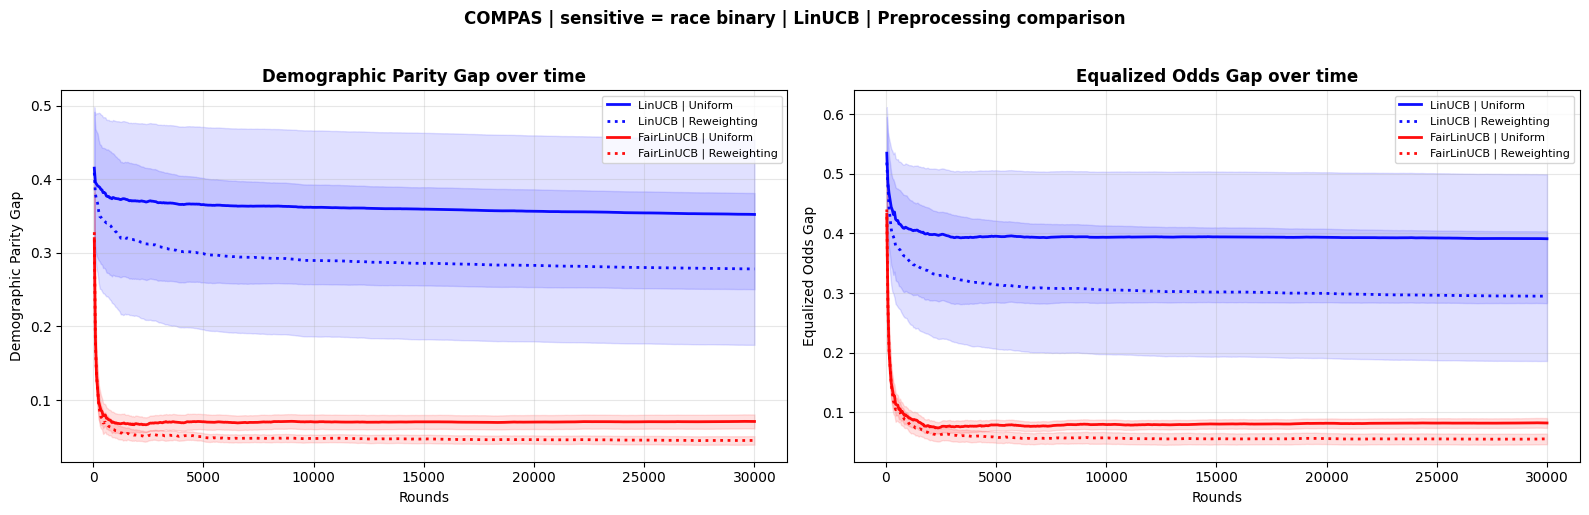

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_inprocessing_fairness.png


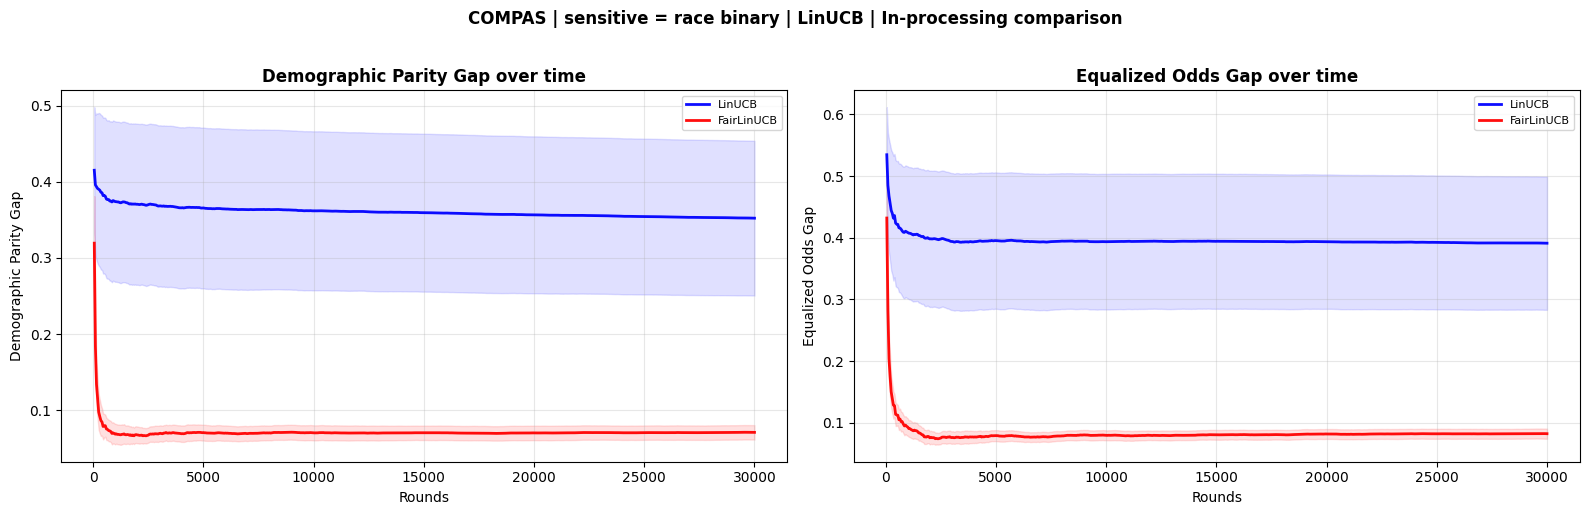

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_average_reward.png


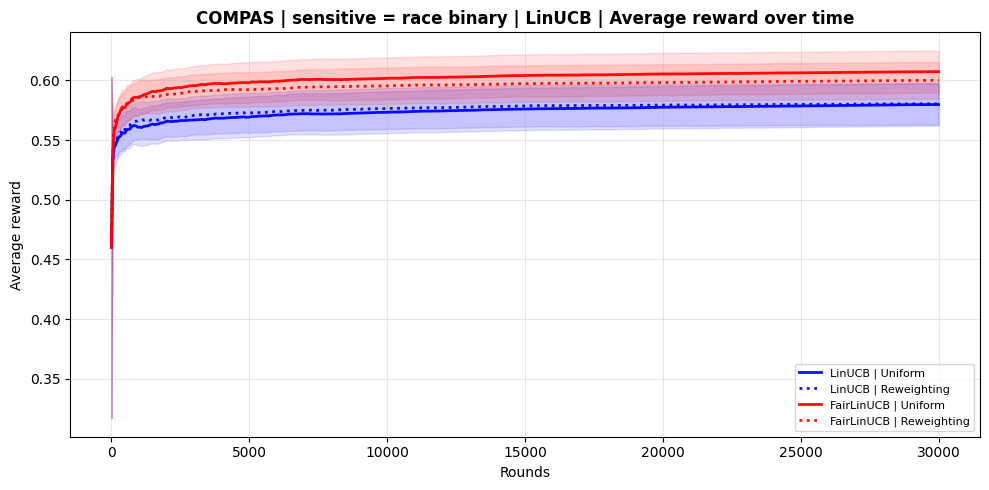

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_cumulative_prediction_error.png


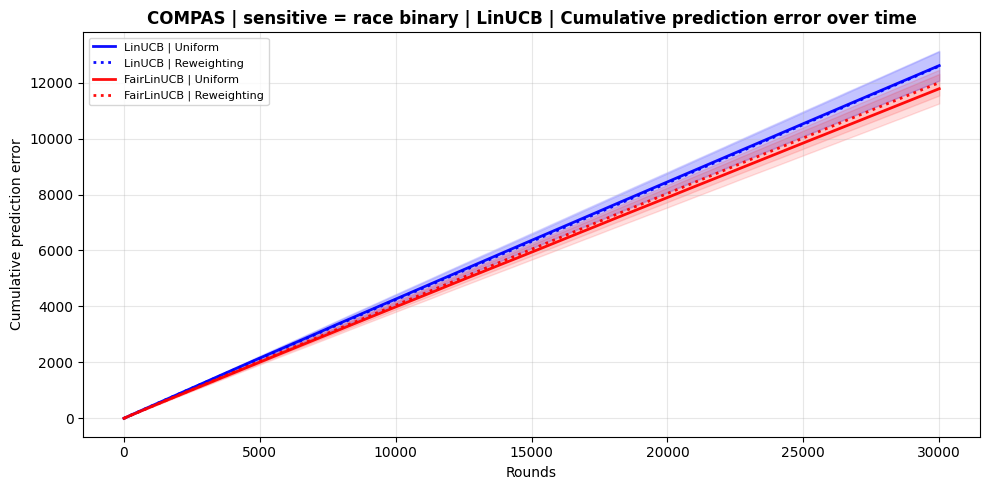

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_utility_gap.png


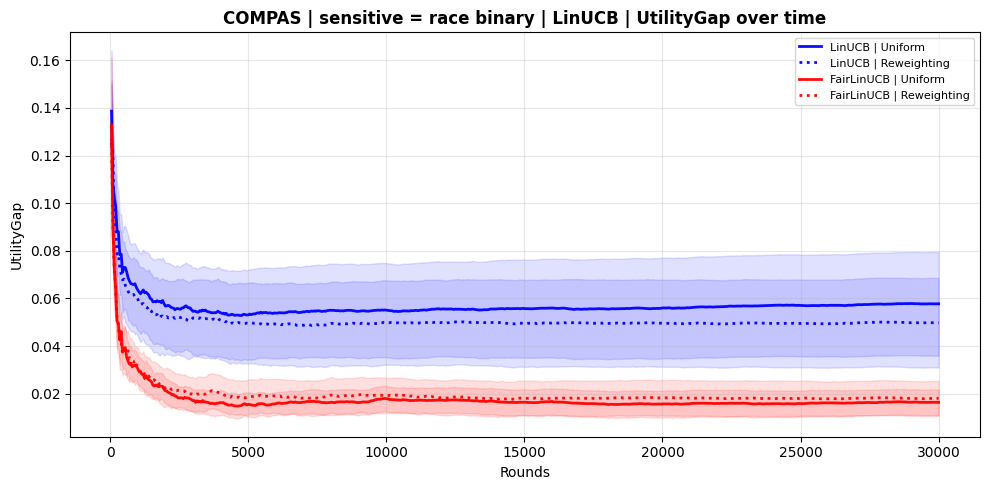

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_final_predictive_performance.png


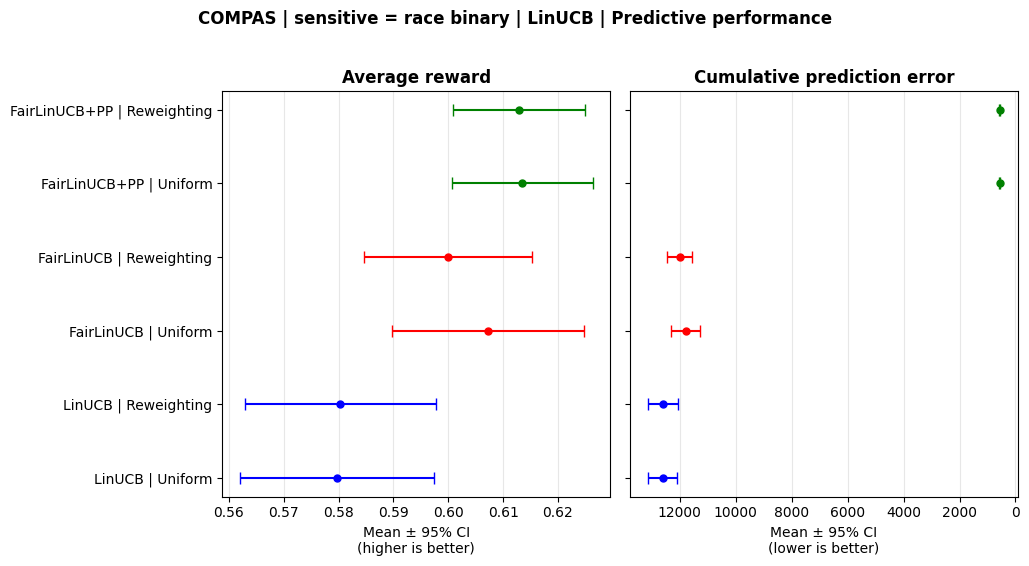

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_final_fairness_performance.png


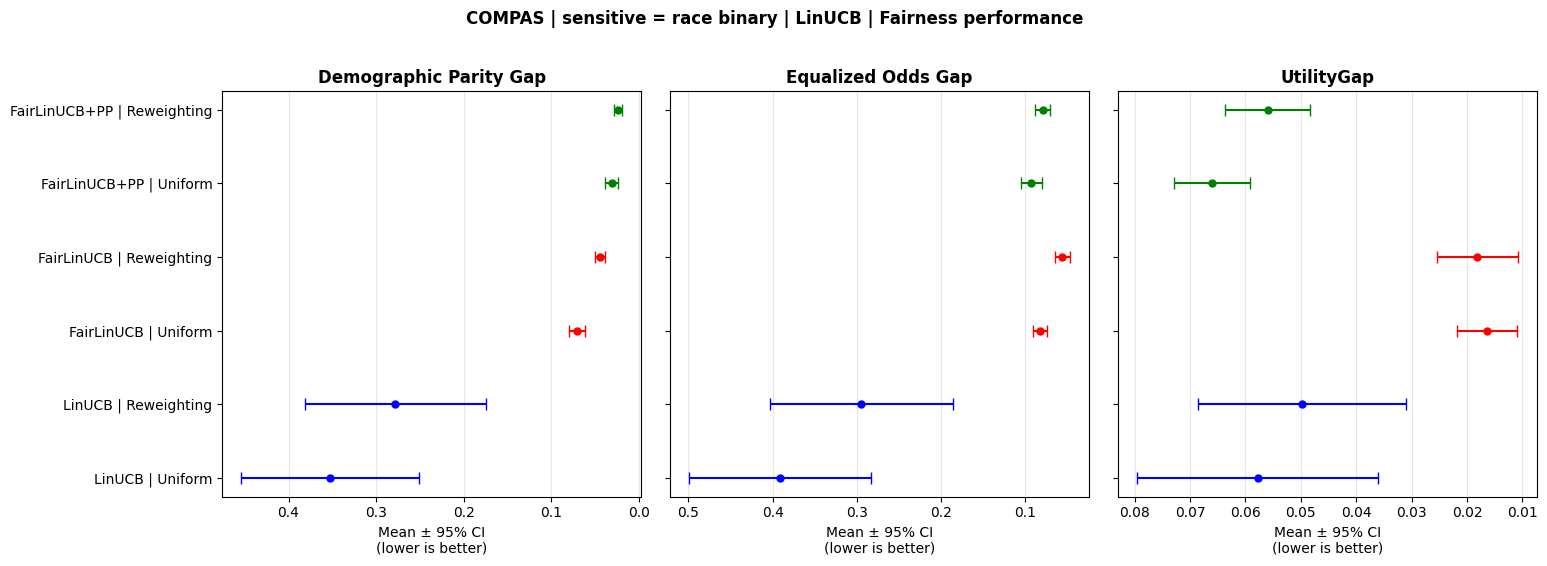

Saved: results\full\compas_race_binary_fairness\final_figures\compas_race_binary_linucb_postprocessing_over_horizon.png


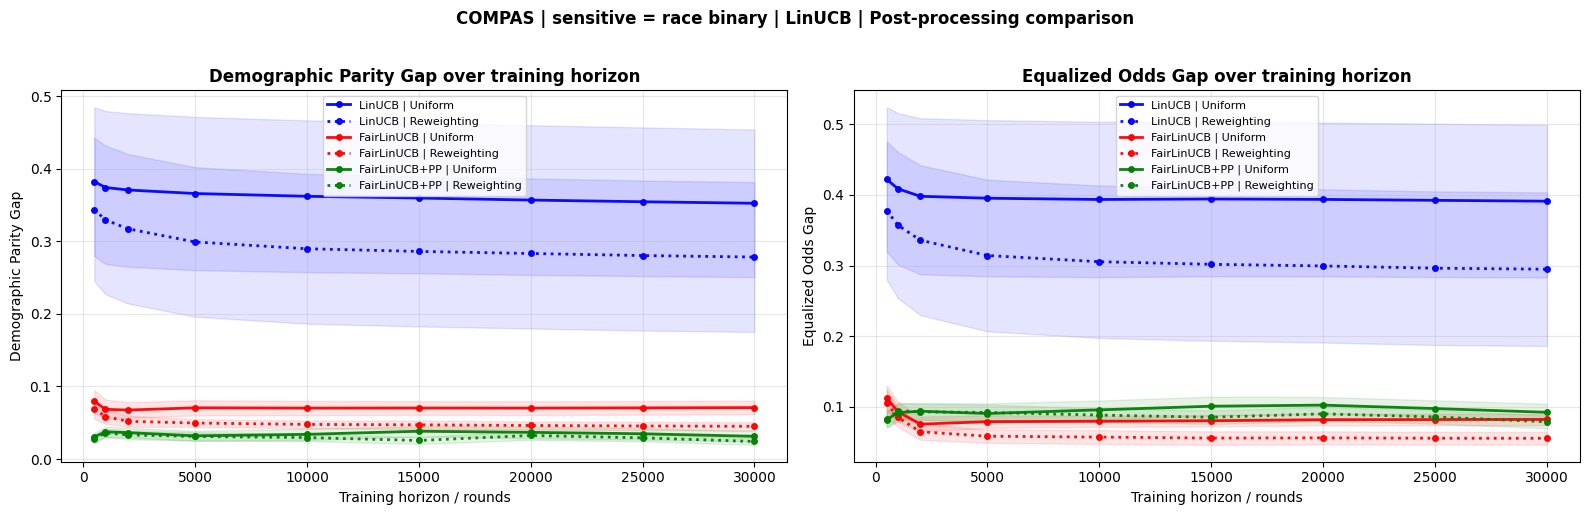

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linear_ts_preprocessing_fairness.png


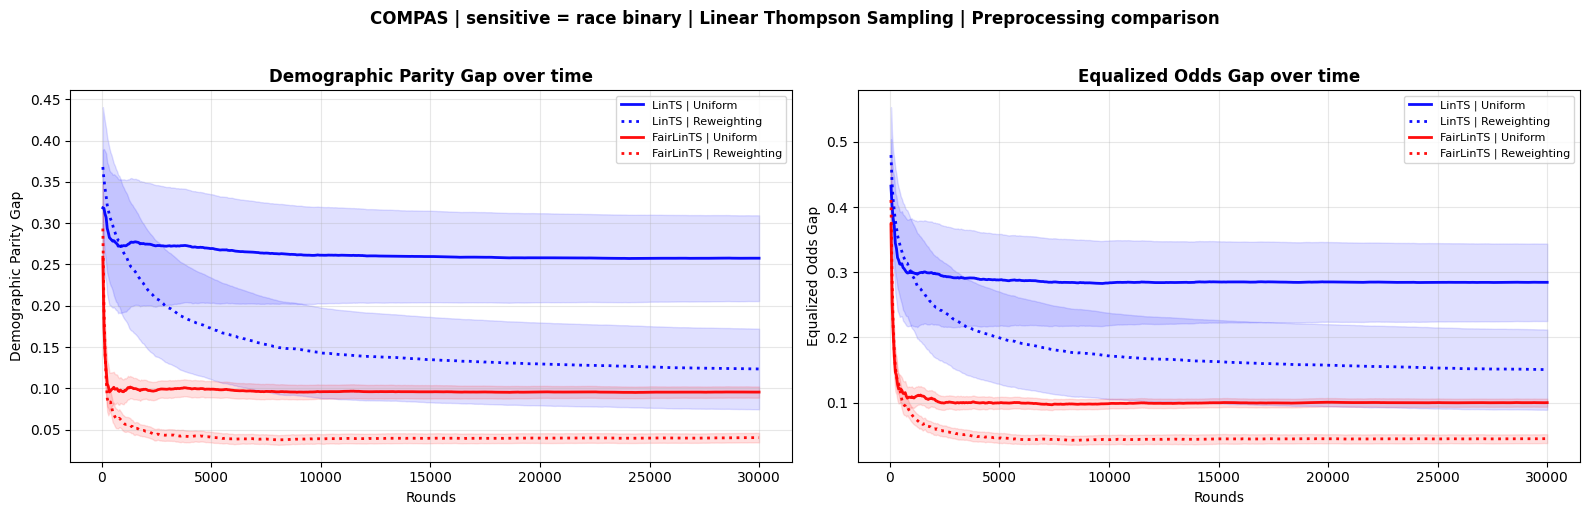

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linear_ts_inprocessing_fairness.png


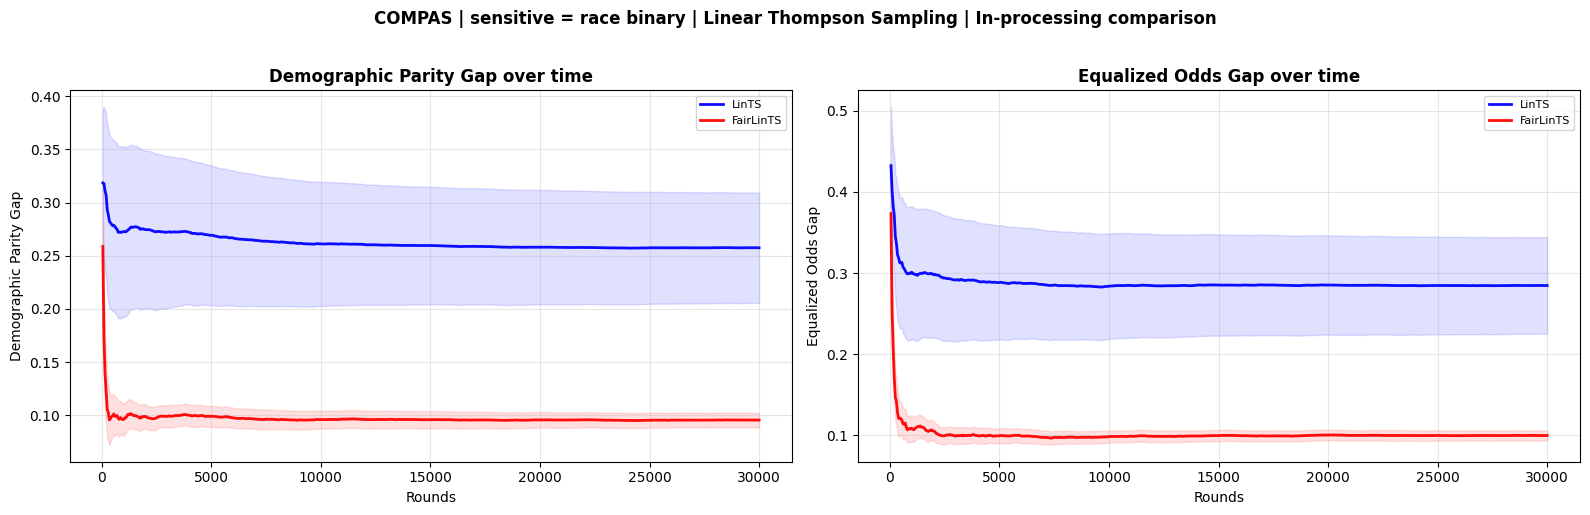

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linear_ts_average_reward.png


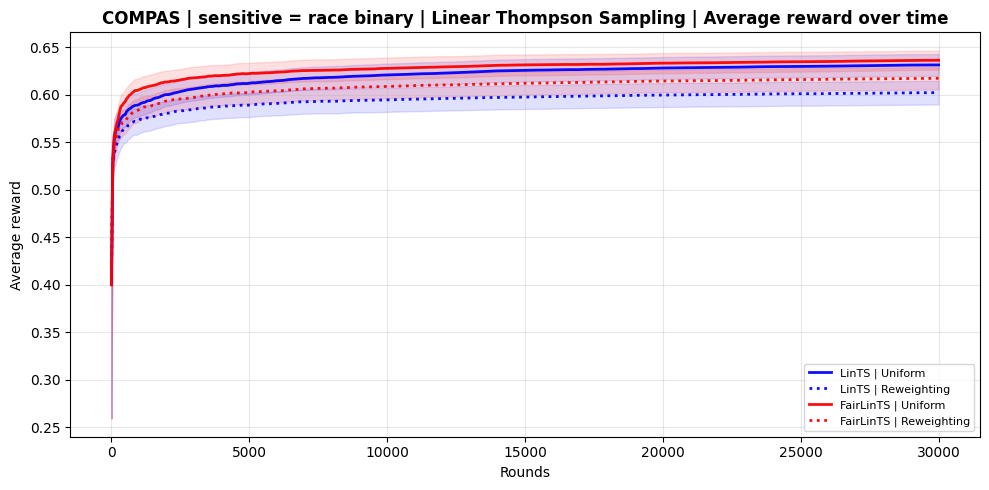

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linear_ts_cumulative_prediction_error.png


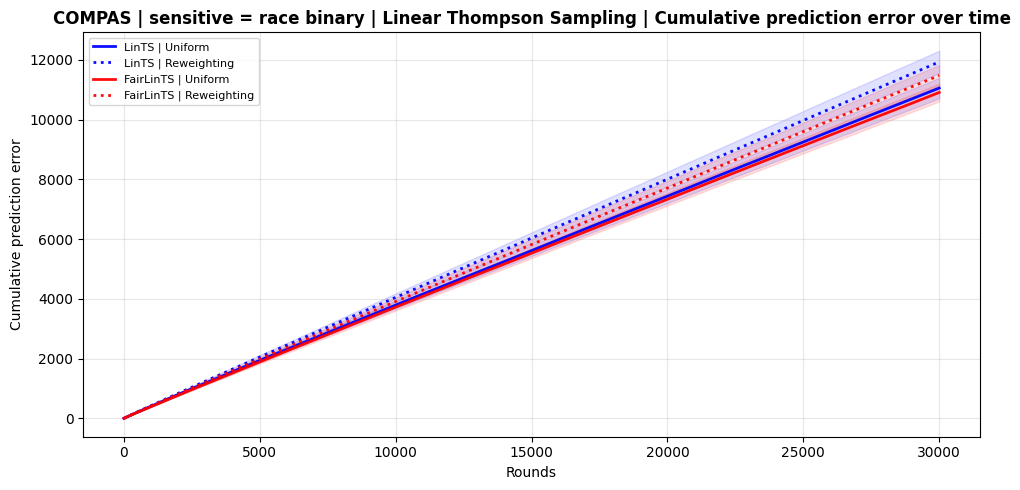

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linear_ts_utility_gap.png


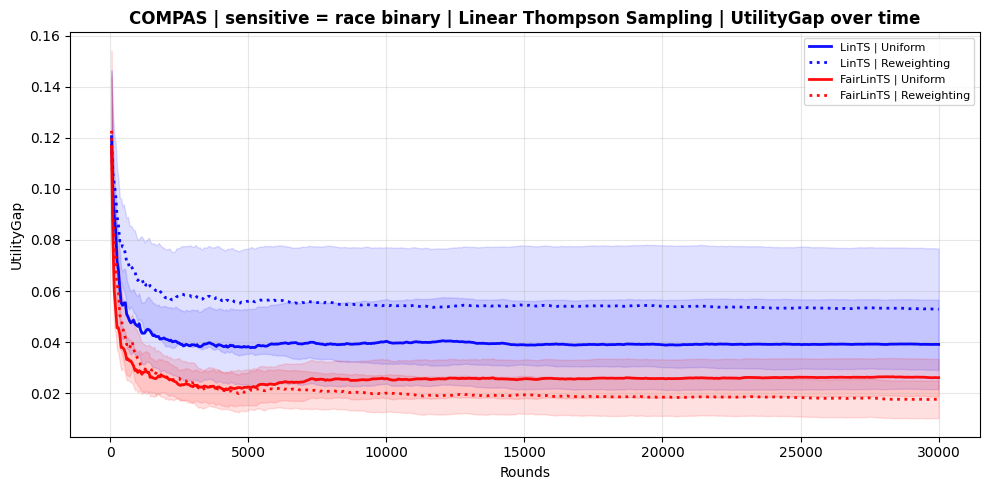

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linear_ts_final_predictive_performance.png


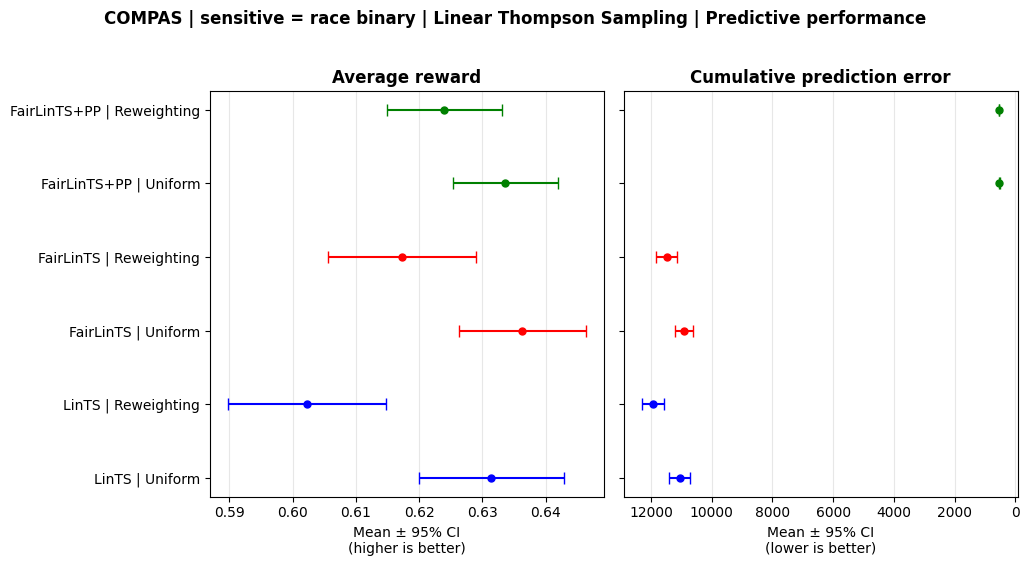

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linear_ts_final_fairness_performance.png


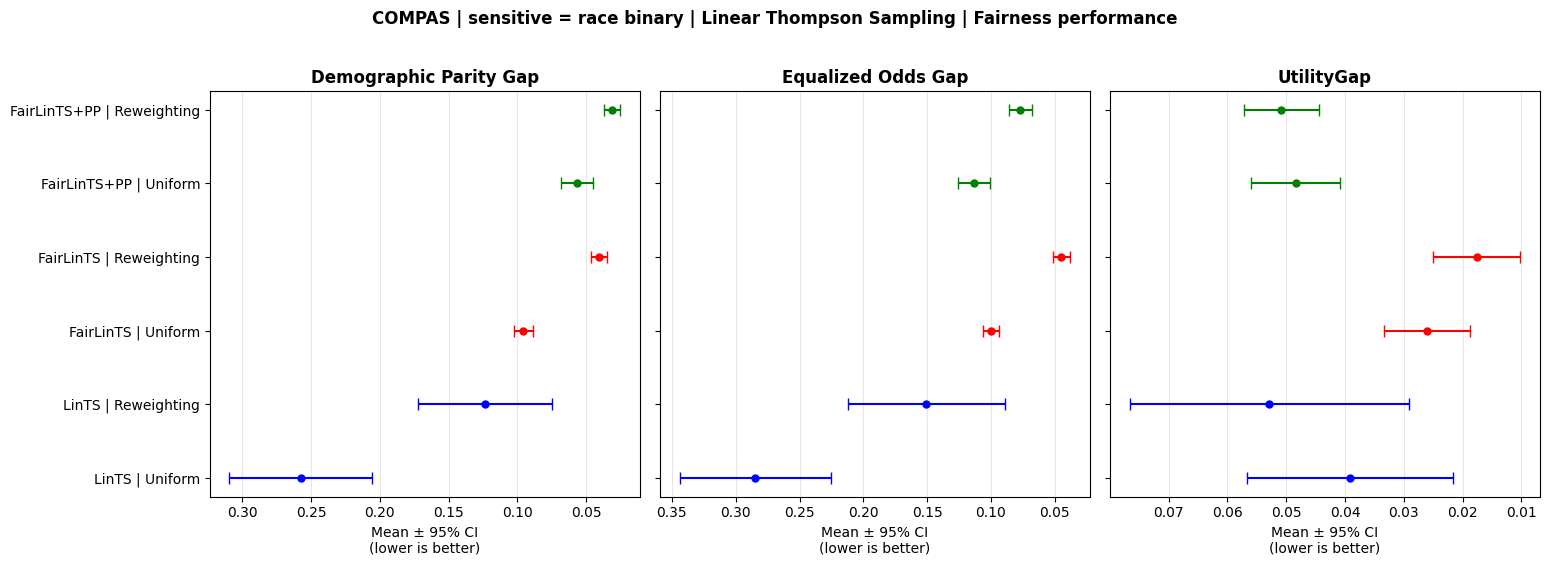

Saved: results\full\compas_race_binary_fairness\final_figures\compas_race_binary_linear_ts_postprocessing_over_horizon.png


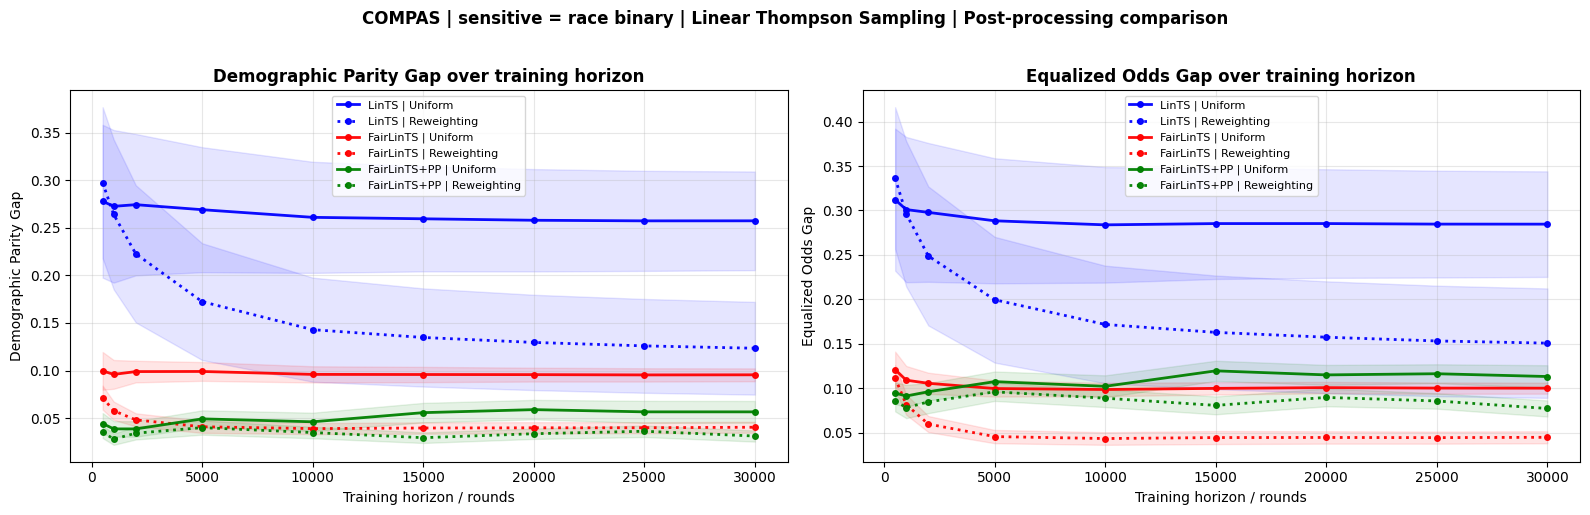

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_exp4_preprocessing_fairness.png


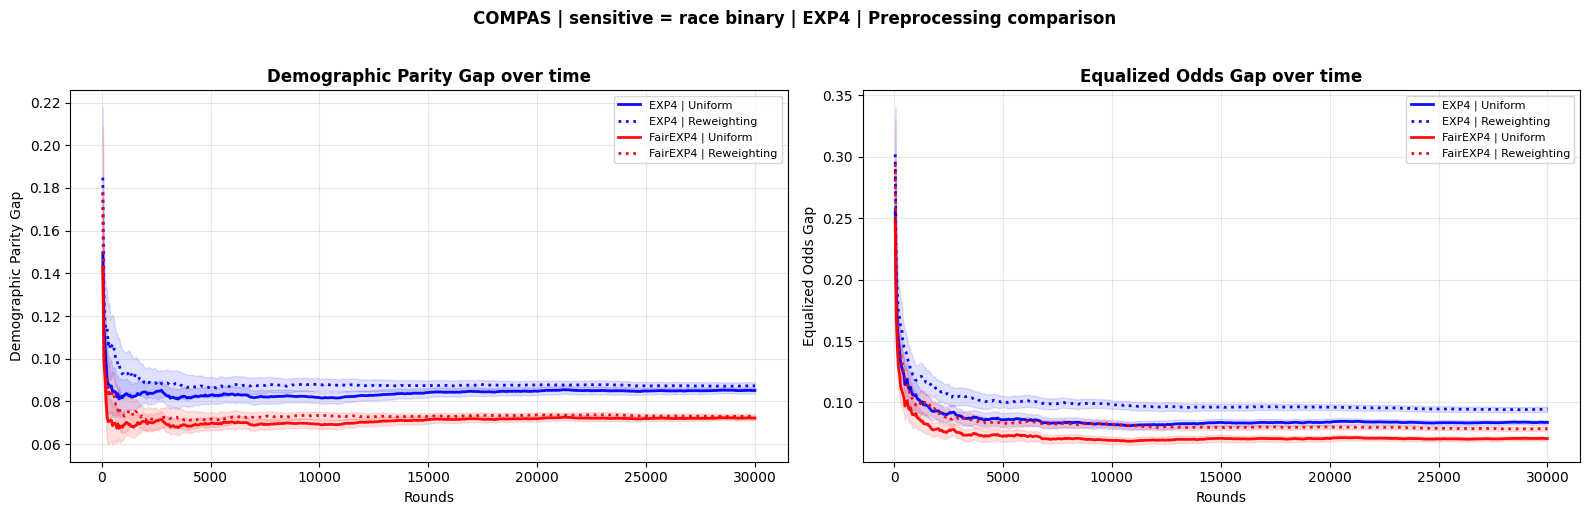

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_exp4_inprocessing_fairness.png


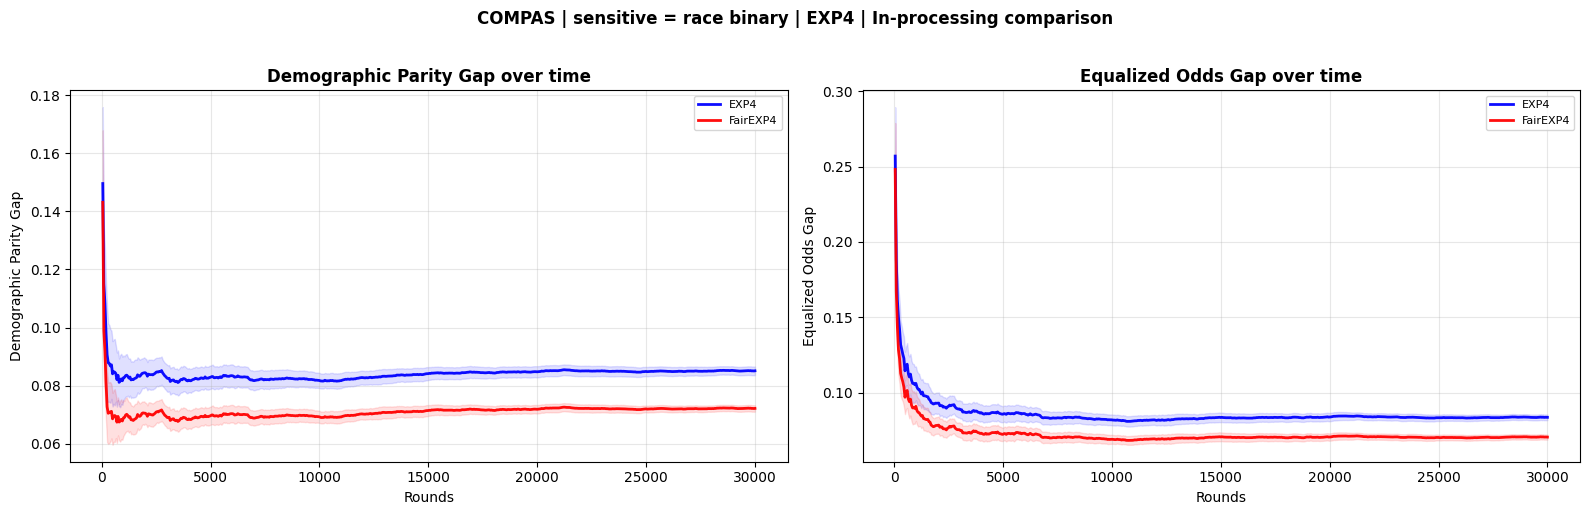

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_exp4_average_reward.png


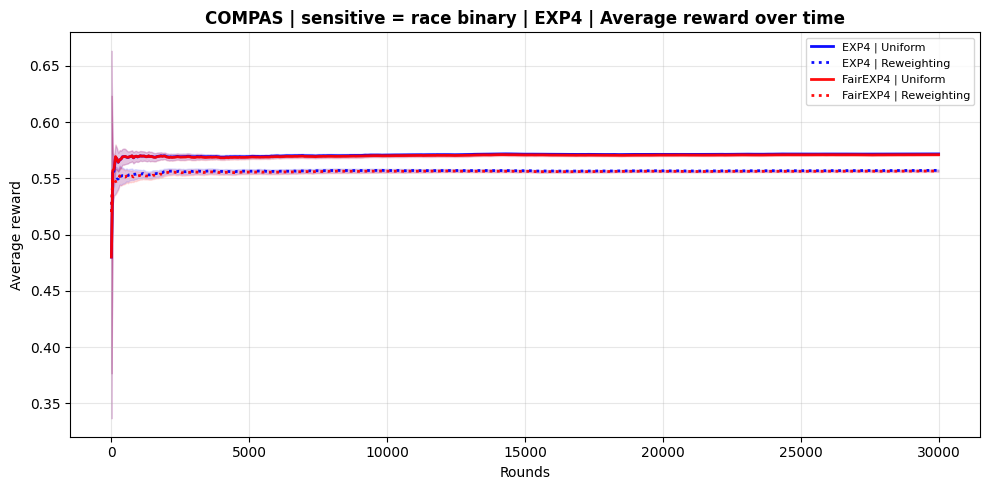

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_exp4_cumulative_prediction_error.png


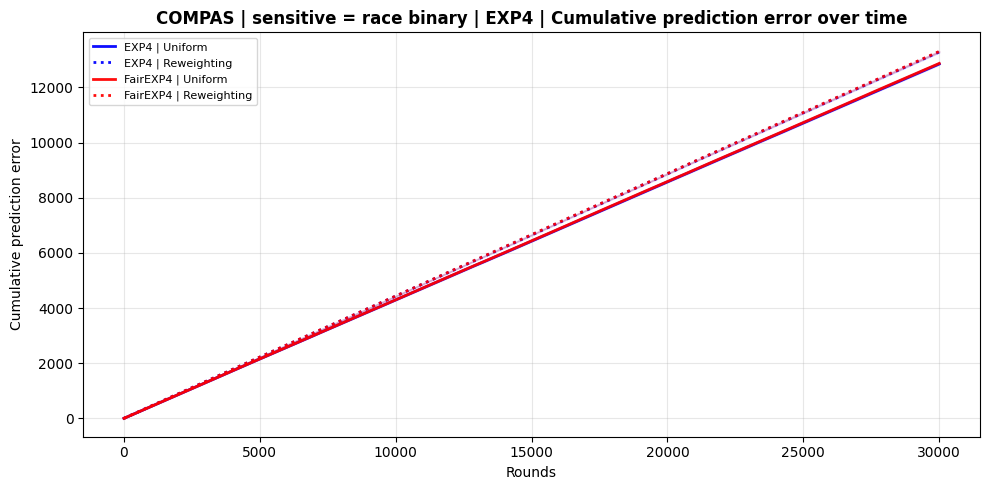

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_exp4_utility_gap.png


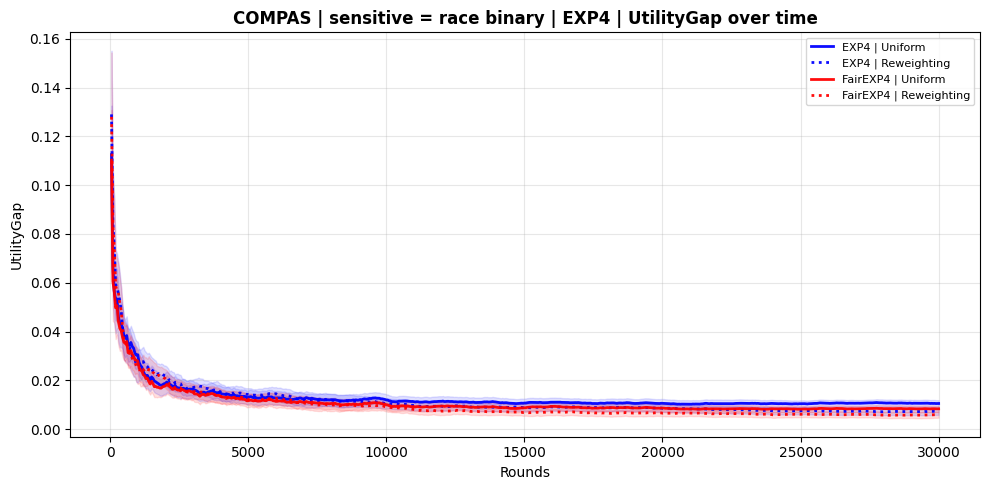

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_exp4_final_predictive_performance.png


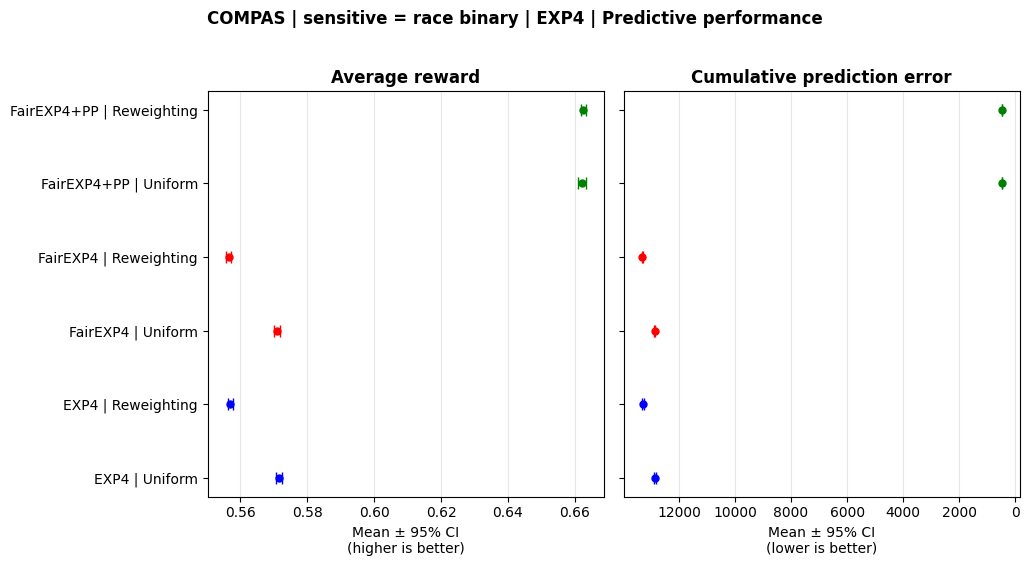

Saved: results\full\compas_race_binary_fairness\final_figures\compas__race_binary_exp4_final_fairness_performance.png


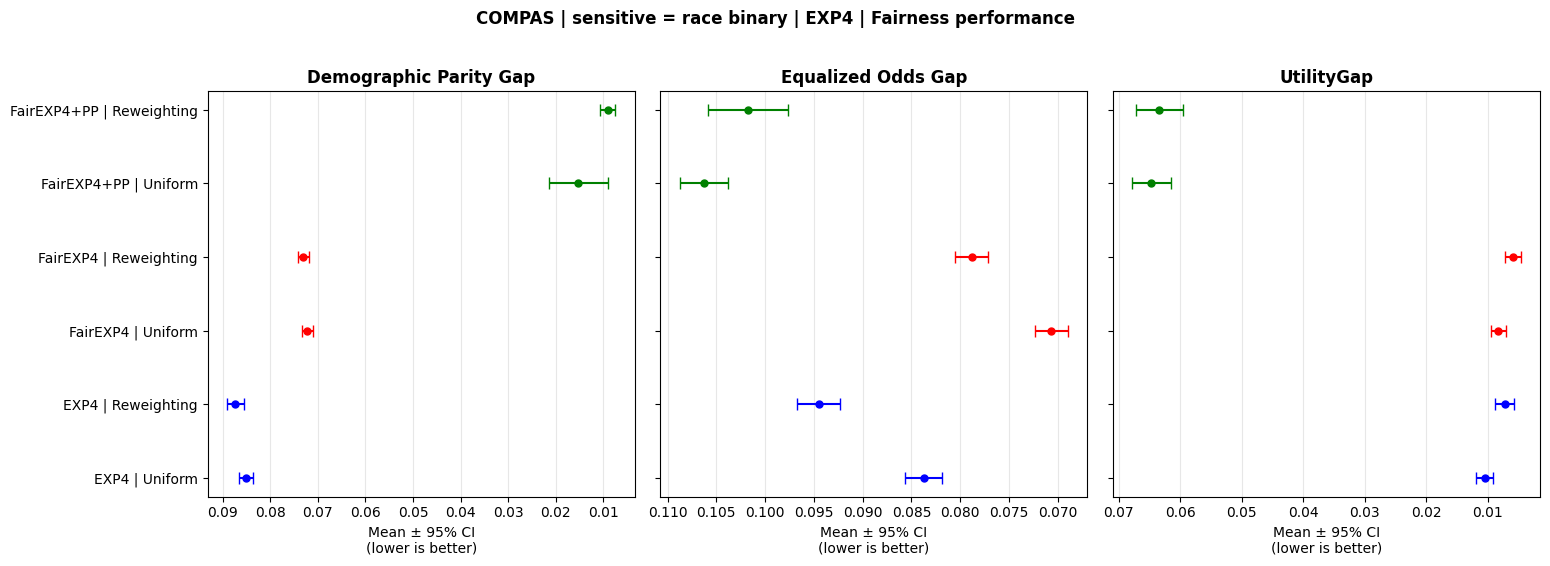

Saved: results\full\compas_race_binary_fairness\final_figures\compas_race_binary_exp4_postprocessing_over_horizon.png


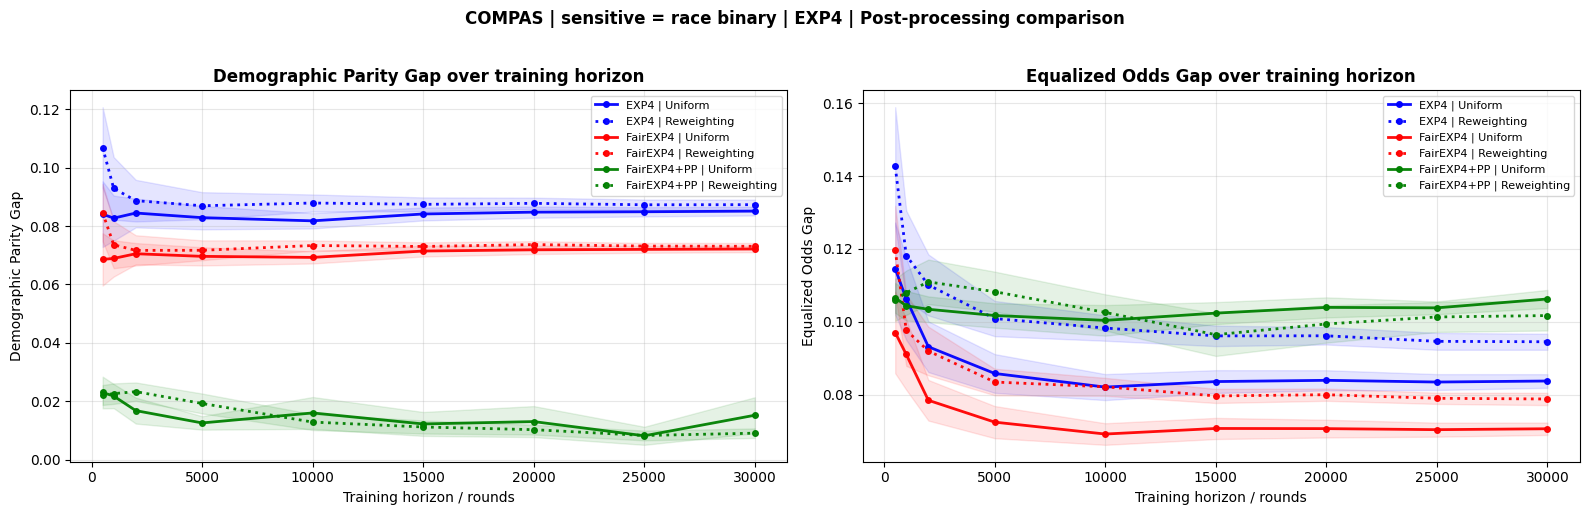

Saved: results\full\compas_race_binary_fairness\final_figures\compas_race_binary_linucb_inprocessing_average_reward_uniform.png


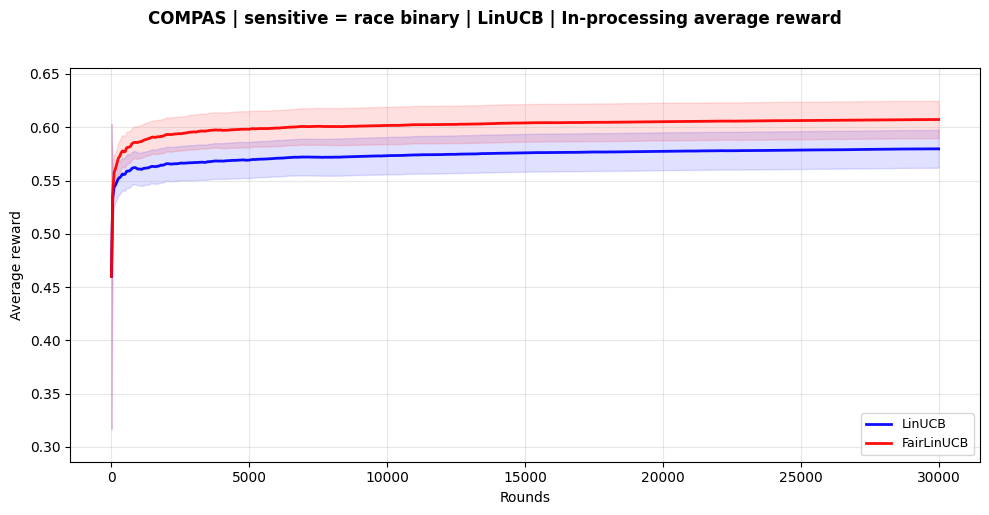

Saved: results\full\compas_race_binary_fairness\final_figures\compas_race_binary_linucb_postprocessing_average_reward_uniform.png


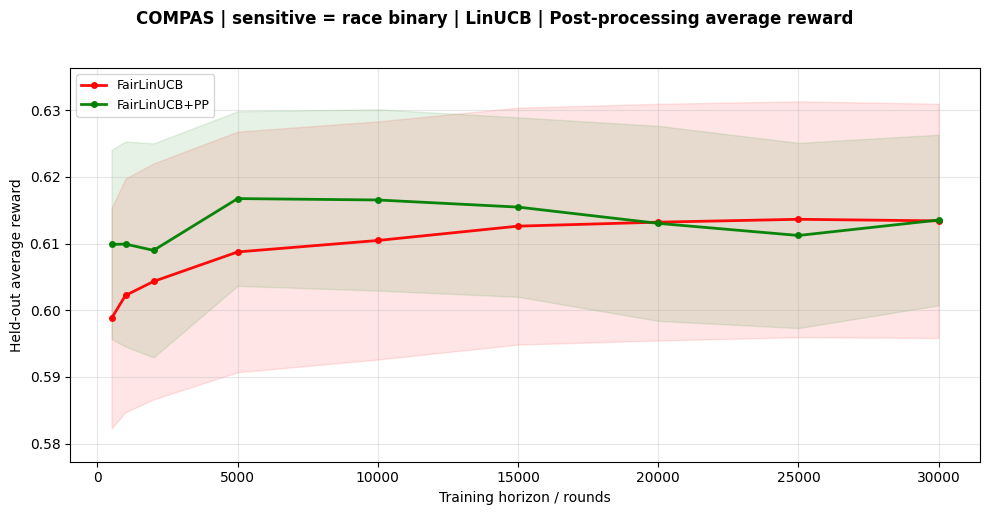

Generated figures: 26
results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_preprocessing_fairness.png
results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_inprocessing_fairness.png
results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_average_reward.png
results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_cumulative_prediction_error.png
results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_utility_gap.png
results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_final_predictive_performance.png
results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linucb_final_fairness_performance.png
results\full\compas_race_binary_fairness\final_figures\compas_race_binary_linucb_postprocessing_over_horizon.png
results\full\compas_race_binary_fairness\final_figures\compas__race_binary_linear_ts_preprocessing_fairness

In [11]:
figure_paths = []

for family, family_config in POLICY_FAMILIES.items():
    figure_paths.extend(
        plot_compas_family_figure_set(
            temporal_df=temporal_df,
            family=family,
            family_label=family_config["label"],
            policies=family_config["policies"],
            preprocessings=PREPROCESSINGS,
            fig_dir=FIG_DIR,
            policy_labels=POLICY_LABELS,
            preprocessing_labels=PREPROCESSING_LABELS,
            show=True,
        )
    )

    figure_paths.extend(
        plot_compas_final_dot_plots(
            endpoint_df=endpoint_df,
            postproc_df=postproc_df,
            family=family,
            family_label=family_config["label"],
            policies=family_config["policies"],
            preprocessings=PREPROCESSINGS,
            fig_dir=FIG_DIR,
            policy_labels=POLICY_LABELS,
            preprocessing_labels=PREPROCESSING_LABELS,
            show=True,
        )
    )

    if not postproc_horizon_df.empty:
        baseline_policy, fair_policy = family_config["policies"]

        family_postproc_horizon_df = postproc_horizon_df[
            postproc_horizon_df["family"] == family
        ].copy()

        if not family_postproc_horizon_df.empty:
            figure_paths.append(
                plot_compas_postprocessing_over_horizon(
                    postproc_horizon_df=family_postproc_horizon_df,
                    temporal_df=temporal_df,
                    family=family,
                    family_label=family_config["label"],
                    baseline_policy=baseline_policy,
                    fair_policy=fair_policy,
                    horizons=POSTPROC_HORIZONS,
                    preprocessings=PREPROCESSINGS,
                    fig_dir=FIG_DIR,
                    policy_labels=POLICY_LABELS,
                    preprocessing_labels=PREPROCESSING_LABELS,
                    show=True,
                )
            )
        else:
            print(
                "Skipping post-processing-over-horizon figure for",
                family,
                "because no longitudinal post-processing data are available.",
            )

# Focused LinUCB in-processing average-reward figure
figure_paths.append(
    plot_compas_linucb_inprocessing_average_reward(
        temporal_df=temporal_df,
        fig_dir=FIG_DIR,
        policy_labels=POLICY_LABELS,
        show=True,
    )
)

# Focused LinUCB post-processing average-reward figure
if not postproc_horizon_df.empty:
    figure_paths.append(
        plot_compas_linucb_postprocessing_average_reward(
            postproc_horizon_df=postproc_horizon_df,
            fig_dir=FIG_DIR,
            policy_labels=POLICY_LABELS,
            show=True,
        )
    )

print("Generated figures:", len(figure_paths))

for path in figure_paths:
    print(path)

## Trade-off plots

Saved: results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_linucb_tradeoff_dp_gap.png


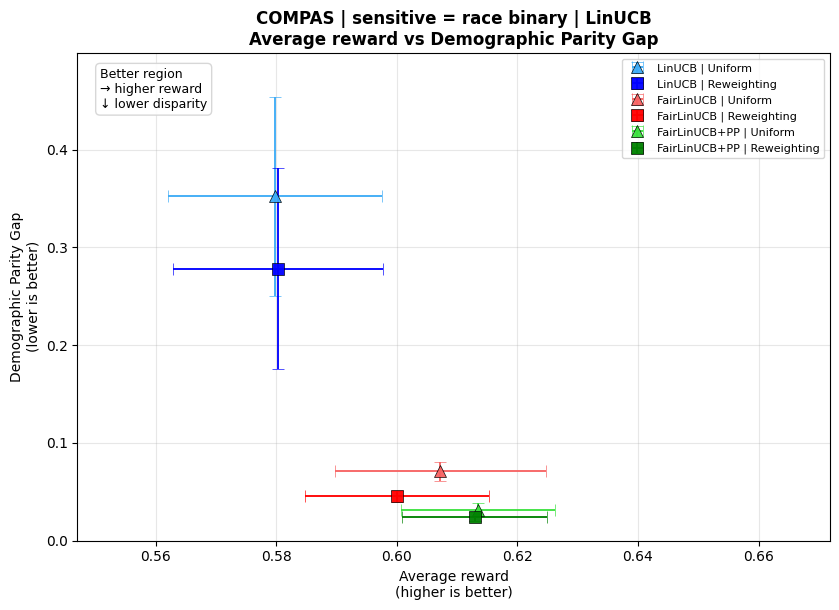

Saved: results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_linucb_tradeoff_eo_gap.png


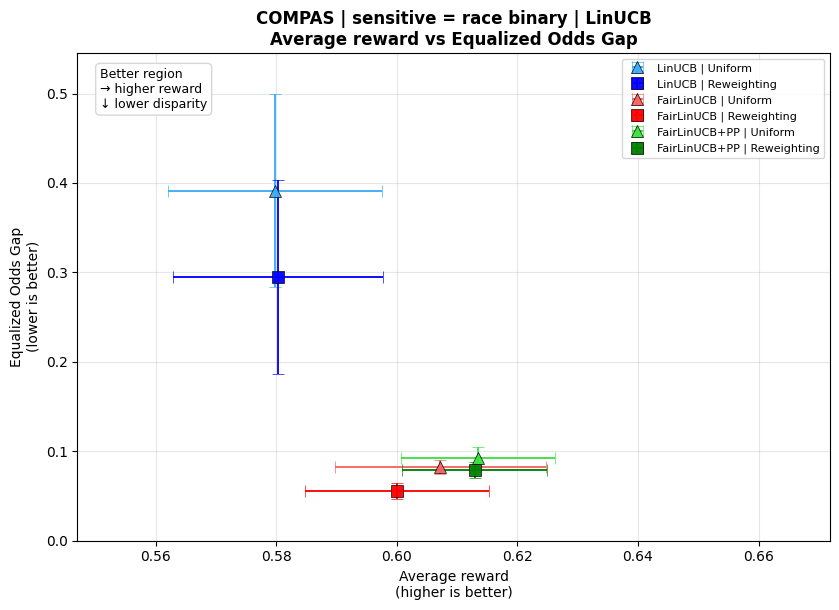

Saved: results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_linear_ts_tradeoff_dp_gap.png


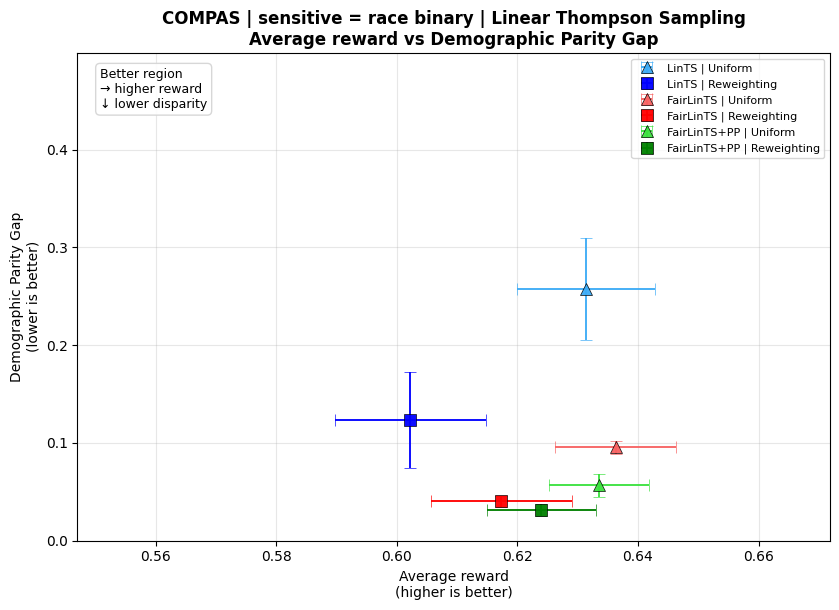

Saved: results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_linear_ts_tradeoff_eo_gap.png


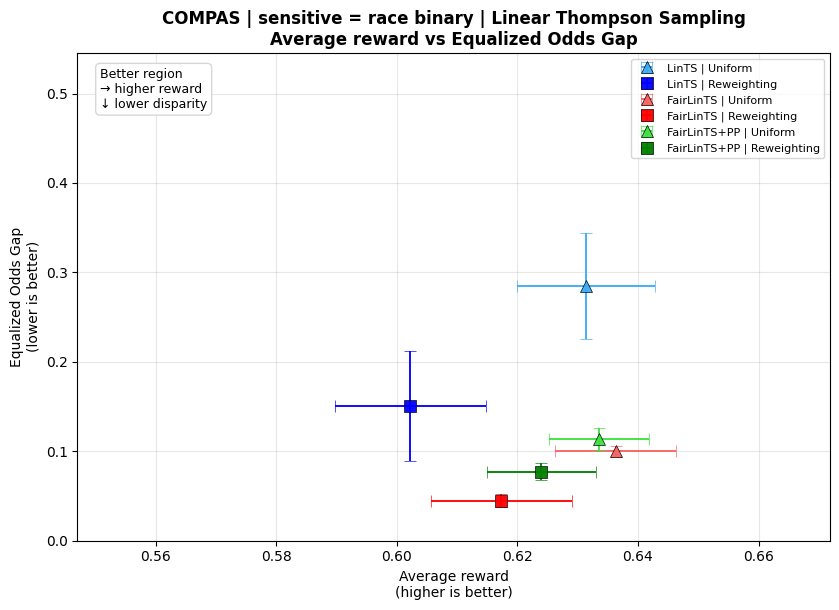

Saved: results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_exp4_tradeoff_dp_gap.png


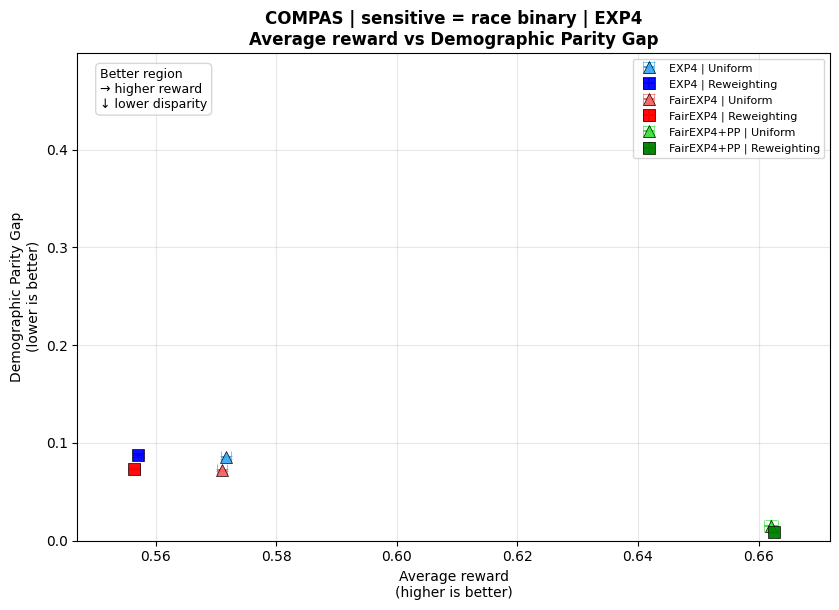

Saved: results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_exp4_tradeoff_eo_gap.png


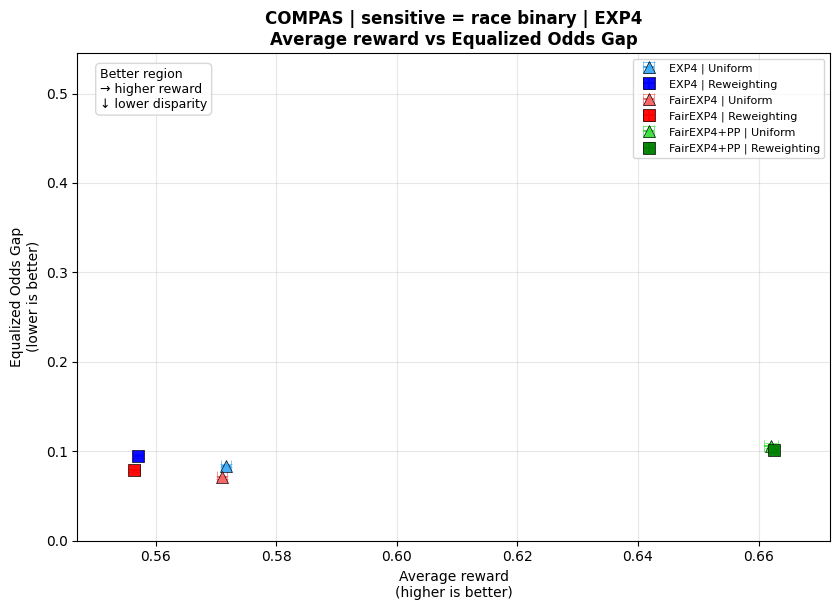

COMPAS trade-off figures: 6
results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_linucb_tradeoff_dp_gap.png
results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_linucb_tradeoff_eo_gap.png
results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_linear_ts_tradeoff_dp_gap.png
results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_linear_ts_tradeoff_eo_gap.png
results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_exp4_tradeoff_dp_gap.png
results\full\compas_race_binary_fairness\final_figures\tradeoff\compas_race_binary_exp4_tradeoff_eo_gap.png


In [12]:
COMPAS_TRADEOFF_DIR = FIG_DIR / "tradeoff"

compas_tradeoff_paths = plot_real_dataset_tradeoff_set(
    dataset_label="COMPAS",
    sensitive_label="race binary",
    endpoint_df=endpoint_df,
    postproc_df=postproc_df,
    policy_families=POLICY_FAMILIES,
    preprocessings=PREPROCESSINGS,
    fig_dir=COMPAS_TRADEOFF_DIR,
    file_prefix="compas_race_binary",
    policy_labels=POLICY_LABELS,
    preprocessing_labels=PREPROCESSING_LABELS,
    confidence=0.95,
    show=True,
)

print("COMPAS trade-off figures:", len(compas_tradeoff_paths))
for path in compas_tradeoff_paths:
    print(path)

## Final summary tables

This section exports compact final summary tables for the COMPAS binary-race experiments.

One table is generated for each policy family: LinUCB, Linear Thompson Sampling, and EXP4. Each table combines the online endpoint results with the held-out post-processed results.

Average reward, cumulative prediction error, Demographic Parity Gap, Equalized Odds Gap, and UtilityGap are reported at the final checkpoint. Values are reported as mean ± standard deviation across seeds.

In [13]:
all_summary_tables = {}

metrics_for_table = [
    ("average_reward", "Average reward"),
    ("cumulative_prediction_error", "Cumulative prediction error"),
    ("DP_gap", "DP gap"),
    ("EO_gap", "EO gap"),
    ("UtilityGap", "UtilityGap"),
]

preprocessing_order = {
    "uniform": 0,
    "reweigh_group_label": 1,
}

for family, family_config in POLICY_FAMILIES.items():
    online_final = (
        endpoint_df[endpoint_df["family"] == family]
        .sort_values("t")
        .groupby(
            ["seed", "policy", "preprocessing"],
            as_index=False,
        )
        .tail(1)
        .copy()
    )

    postprocessed_policy = family_config["postprocessed_policy"]

    heldout_postproc = (
        postproc_df[
            (postproc_df["family"] == family)
            & (postproc_df["policy"] == postprocessed_policy)
        ]
        .copy()
    )

    performance_source = pd.concat(
        [
            online_final,
            heldout_postproc,
        ],
        ignore_index=True,
    )

    policy_order = {
        family_config["policies"][0]: 0,
        family_config["policies"][1]: 1,
        postprocessed_policy: 2,
    }

    rows = []

    for (policy, preprocessing), group_df in performance_source.groupby(
        ["policy", "preprocessing"]
    ):
        row = {
            "Policy": POLICY_LABELS.get(policy, policy),
            "Preprocessing": PREPROCESSING_LABELS.get(
                preprocessing,
                preprocessing,
            ),
            "Seeds": int(group_df["seed"].nunique()),
        }

        for metric, label in metrics_for_table:
            row[label] = fmt_mean_sd(group_df[metric])

        row["_policy_order"] = policy_order.get(policy, 99)
        row["_preprocessing_order"] = preprocessing_order.get(
            preprocessing,
            99,
        )

        rows.append(row)

    table = (
        pd.DataFrame(rows)
        .sort_values(
            [
                "_policy_order",
                "_preprocessing_order",
            ]
        )
        .drop(
            columns=[
                "_policy_order",
                "_preprocessing_order",
            ]
        )
        .reset_index(drop=True)
    )

    all_summary_tables[family] = table

    display(table)

    csv_path = (
        TABLE_DIR
        / f"compas_race_binary_{family}_performance_summary.csv"
    )

    tex_path = (
        TABLE_DIR
        / f"compas_race_binary_{family}_performance_summary.tex"
    )

    table.to_csv(
        csv_path,
        index=False,
    )

    export_latex_table(
        table,
        tex_path,
        caption=(
            f"Final performance summary for the COMPAS dataset using binary race "
            f"as sensitive attribute and {family_config['label']}, including "
            f"post-processing. Values are reported as mean $\\pm$ standard "
            f"deviation across seeds."
        ),
        label=f"tab:compas_race_binary_{family}_performance_summary",
    )

    print("Saved:", csv_path)
    print("Saved:", tex_path)

,Policy,Preprocessing,Seeds,Average reward,Cumulative prediction error,DP gap,EO gap,UtilityGap
0,LinUCB,Uniform,50,0.5797 $\pm$ 0.0624,12607.9400 $\pm$ 1872.8092,0.3523 $\pm$ 0.3577,0.3911 $\pm$ 0.3801,0.0578 $\pm$ 0.0765
1,LinUCB,Reweighting,50,0.5803 $\pm$ 0.0613,12590.8200 $\pm$ 1838.6718,0.2782 $\pm$ 0.3633,0.2948 $\pm$ 0.3826,0.0498 $\pm$ 0.0660
2,FairLinUCB,Uniform,50,0.6072 $\pm$ 0.0617,11782.6600 $\pm$ 1851.8863,0.0708 $\pm$ 0.0333,0.0822 $\pm$ 0.0289,0.0164 $\pm$ 0.0191
3,FairLinUCB,Reweighting,50,0.6000 $\pm$ 0.0539,11999.0800 $\pm$ 1617.3465,0.0450 $\pm$ 0.0204,0.0555 $\pm$ 0.0314,0.0181 $\pm$ 0.0257
4,FairLinUCB+PP,Uniform,50,0.6135 $\pm$ 0.0450,557.6800 $\pm$ 64.9422,0.0313 $\pm$ 0.0251,0.0923 $\pm$ 0.0429,0.0660 $\pm$ 0.0244
5,FairLinUCB+PP,Reweighting,50,0.6129 $\pm$ 0.0425,558.6000 $\pm$ 61.3667,0.0242 $\pm$ 0.0163,0.0788 $\pm$ 0.0322,0.0560 $\pm$ 0.0268


Saved: results\full\compas_race_binary_fairness\overleaf_tables\compas_race_binary_linucb_performance_summary.csv
Saved: results\full\compas_race_binary_fairness\overleaf_tables\compas_race_binary_linucb_performance_summary.tex


,Policy,Preprocessing,Seeds,Average reward,Cumulative prediction error,DP gap,EO gap,UtilityGap
0,LinTS,Uniform,50,0.6314 $\pm$ 0.0403,11057.4200 $\pm$ 1209.5106,0.2575 $\pm$ 0.1826,0.2846 $\pm$ 0.2090,0.0391 $\pm$ 0.0615
1,LinTS,Reweighting,50,0.6022 $\pm$ 0.0439,11932.8400 $\pm$ 1317.5509,0.1234 $\pm$ 0.1716,0.1507 $\pm$ 0.2166,0.0529 $\pm$ 0.0836
2,FairLinTS,Uniform,50,0.6363 $\pm$ 0.0354,10910.5200 $\pm$ 1060.9389,0.0955 $\pm$ 0.0238,0.1000 $\pm$ 0.0219,0.0261 $\pm$ 0.0258
3,FairLinTS,Reweighting,50,0.6173 $\pm$ 0.0413,11480.3400 $\pm$ 1238.3666,0.0403 $\pm$ 0.0203,0.0448 $\pm$ 0.0238,0.0176 $\pm$ 0.0260
4,FairLinTS+PP,Uniform,50,0.6336 $\pm$ 0.0292,528.7000 $\pm$ 42.1403,0.0565 $\pm$ 0.0404,0.1131 $\pm$ 0.0447,0.0484 $\pm$ 0.0265
5,FairLinTS+PP,Reweighting,50,0.6240 $\pm$ 0.0319,542.6400 $\pm$ 46.0513,0.0310 $\pm$ 0.0206,0.0772 $\pm$ 0.0318,0.0509 $\pm$ 0.0224


Saved: results\full\compas_race_binary_fairness\overleaf_tables\compas_race_binary_linear_ts_performance_summary.csv
Saved: results\full\compas_race_binary_fairness\overleaf_tables\compas_race_binary_linear_ts_performance_summary.tex


,Policy,Preprocessing,Seeds,Average reward,Cumulative prediction error,DP gap,EO gap,UtilityGap
0,EXP4,Uniform,50,0.5717 $\pm$ 0.0032,12850.3600 $\pm$ 94.6859,0.0851 $\pm$ 0.0053,0.0838 $\pm$ 0.0066,0.0105 $\pm$ 0.0048
1,EXP4,Reweighting,50,0.5571 $\pm$ 0.0030,13288.0200 $\pm$ 90.0695,0.0873 $\pm$ 0.0061,0.0945 $\pm$ 0.0077,0.0073 $\pm$ 0.0052
2,FairEXP4,Uniform,50,0.5710 $\pm$ 0.0032,12870.0800 $\pm$ 95.1984,0.0722 $\pm$ 0.0039,0.0706 $\pm$ 0.0060,0.0083 $\pm$ 0.0044
3,FairEXP4,Reweighting,50,0.5565 $\pm$ 0.0030,13305.3400 $\pm$ 89.7228,0.0731 $\pm$ 0.0040,0.0788 $\pm$ 0.0059,0.0059 $\pm$ 0.0044
4,FairEXP4+PP,Uniform,50,0.6621 $\pm$ 0.0040,487.6400 $\pm$ 5.7703,0.0152 $\pm$ 0.0217,0.1063 $\pm$ 0.0088,0.0647 $\pm$ 0.0109
5,FairEXP4+PP,Reweighting,50,0.6625 $\pm$ 0.0026,487.0000 $\pm$ 3.7688,0.0091 $\pm$ 0.0057,0.1017 $\pm$ 0.0144,0.0634 $\pm$ 0.0133


Saved: results\full\compas_race_binary_fairness\overleaf_tables\compas_race_binary_exp4_performance_summary.csv
Saved: results\full\compas_race_binary_fairness\overleaf_tables\compas_race_binary_exp4_performance_summary.tex


## Paired significance tests

This section performs paired Wilcoxon signed-rank tests across seeds.

The comparisons are defined separately for each policy family and cover the three intervention levels:

- preprocessing: baseline policy under uniform preprocessing versus reweighting;
- in-processing: baseline policy versus its fairness-aware variant;
- post-processing: fairness-aware policy before versus after group-specific threshold calibration.

Online comparisons are evaluated at the final online endpoint. Post-processing comparisons are evaluated on the held-out test set. Holm correction is applied for multiple comparisons.


In [14]:
def safe_wilcoxon(
    baseline,
    intervention,
) -> float:
    baseline = np.asarray(
        baseline,
        dtype=float,
    )

    intervention = np.asarray(
        intervention,
        dtype=float,
    )

    mask = (
        np.isfinite(baseline)
        & np.isfinite(intervention)
    )

    baseline = baseline[mask]
    intervention = intervention[mask]

    if len(baseline) == 0:
        return np.nan

    if np.allclose(
        baseline,
        intervention,
    ):
        return 1.0

    return float(
        wilcoxon(
            baseline,
            intervention,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto",
        ).pvalue
    )


def holm_adjust(
    p_values,
) -> np.ndarray:
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    p_values = np.where(
        np.isfinite(p_values),
        p_values,
        1.0,
    )

    order = np.argsort(p_values)

    adjusted = np.empty(
        len(p_values),
        dtype=float,
    )

    previous = 0.0

    for rank, index in enumerate(order):
        value = (
            len(p_values)
            - rank
        ) * p_values[index]

        value = min(
            max(
                value,
                previous,
            ),
            1.0,
        )

        adjusted[index] = value
        previous = value

    return adjusted


def format_p_value(
    p_value,
) -> str:
    if not np.isfinite(p_value):
        return "--"

    if p_value < 0.001:
        return "<0.001"

    return f"{p_value:.3f}"


def format_significance(
    p_value,
) -> str:
    if not np.isfinite(p_value):
        return ""

    return "*" if p_value < 0.05 else ""


def ensure_cumulative_prediction_error(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    df = dataframe.copy()

    if (
        "cumulative_prediction_error" not in df.columns
        and "cumulative_regret" in df.columns
    ):
        df["cumulative_prediction_error"] = df["cumulative_regret"]

    return df


online_final_stats = (
    ensure_cumulative_prediction_error(endpoint_df)
    .sort_values("t")
    .groupby(
        [
            "family",
            "seed",
            "policy",
            "preprocessing",
        ],
        as_index=False,
    )
    .tail(1)
    .copy()
)

heldout_postproc_stats = ensure_cumulative_prediction_error(
    postproc_df
)


online_metrics = [
    ("DP_gap", "DP gap"),
    ("EO_gap", "EO gap"),
    ("UtilityGap", "UtilityGap"),
    ("average_reward", "Average reward"),
    ("cumulative_prediction_error", "Cumulative prediction error"),
]

heldout_metrics = [
    ("DP_gap", "DP gap"),
    ("EO_gap", "EO gap"),
    ("UtilityGap", "UtilityGap"),
    ("average_reward", "Average reward"),
]


rows = []

for family, family_config in POLICY_FAMILIES.items():
    baseline_policy, fair_policy = family_config["policies"]
    postprocessed_policy = family_config["postprocessed_policy"]

    family_label = family_config["label"]

    comparisons = [
        (
            "Preprocessing effect",
            "online",
            baseline_policy,
            "uniform",
            baseline_policy,
            "reweigh_group_label",
            f"{baseline_policy} | Uniform",
            f"{baseline_policy} | Reweighting",
        ),
        (
            "Preprocessing effect",
            "online",
            fair_policy,
            "uniform",
            fair_policy,
            "reweigh_group_label",
            f"{fair_policy} | Uniform",
            f"{fair_policy} | Reweighting",
        ),
        (
            "In-processing effect",
            "online",
            baseline_policy,
            "uniform",
            fair_policy,
            "uniform",
            f"{baseline_policy} | Uniform",
            f"{fair_policy} | Uniform",
        ),
        (
            "In-processing effect",
            "online",
            baseline_policy,
            "reweigh_group_label",
            fair_policy,
            "reweigh_group_label",
            f"{baseline_policy} | Reweighting",
            f"{fair_policy} | Reweighting",
        ),
        (
            "Post-processing effect",
            "heldout",
            fair_policy,
            "uniform",
            postprocessed_policy,
            "uniform",
            f"{fair_policy} | Uniform",
            f"{postprocessed_policy} | Uniform",
        ),
        (
            "Post-processing effect",
            "heldout",
            fair_policy,
            "reweigh_group_label",
            postprocessed_policy,
            "reweigh_group_label",
            f"{fair_policy} | Reweighting",
            f"{postprocessed_policy} | Reweighting",
        ),
    ]

    for (
        comparison,
        source_name,
        baseline_policy_name,
        baseline_preprocessing,
        intervention_policy_name,
        intervention_preprocessing,
        baseline_label,
        intervention_label,
    ) in comparisons:
        if source_name == "online":
            source_df = online_final_stats[
                online_final_stats["family"] == family
            ].copy()

            metrics = online_metrics

        else:
            source_df = heldout_postproc_stats[
                heldout_postproc_stats["family"] == family
            ].copy()

            metrics = heldout_metrics

        for metric, metric_label in metrics:
            if metric not in source_df.columns:
                print(
                    "Skipping missing metric:",
                    family,
                    metric,
                )
                continue

            baseline = (
                source_df[
                    (
                        source_df["policy"]
                        == baseline_policy_name
                    )
                    & (
                        source_df["preprocessing"]
                        == baseline_preprocessing
                    )
                ][
                    [
                        "seed",
                        metric,
                    ]
                ]
                .rename(
                    columns={
                        metric: "baseline_value",
                    }
                )
            )

            intervention = (
                source_df[
                    (
                        source_df["policy"]
                        == intervention_policy_name
                    )
                    & (
                        source_df["preprocessing"]
                        == intervention_preprocessing
                    )
                ][
                    [
                        "seed",
                        metric,
                    ]
                ]
                .rename(
                    columns={
                        metric: "intervention_value",
                    }
                )
            )

            paired = baseline.merge(
                intervention,
                on="seed",
                how="inner",
                validate="one_to_one",
            )

            if paired.empty:
                print(
                    "Skipping empty paired comparison:",
                    family,
                    comparison,
                    metric_label,
                    baseline_label,
                    intervention_label,
                )
                continue

            raw_p = safe_wilcoxon(
                paired["baseline_value"],
                paired["intervention_value"],
            )

            rows.append(
                {
                    "Family": family_label,
                    "Comparison": comparison,
                    "Metric": metric_label,
                    "Baseline": baseline_label,
                    "Intervention": intervention_label,
                    "Baseline value": fmt_mean_sd(
                        paired["baseline_value"]
                    ),
                    "Intervention value": fmt_mean_sd(
                        paired["intervention_value"]
                    ),
                    "p_raw": raw_p,
                    "n_pairs": int(
                        paired["seed"].nunique()
                    ),
                }
            )


compas_race_binary_significance_detailed = pd.DataFrame(
    rows
)

compas_race_binary_significance_detailed[
    "p_holm"
] = holm_adjust(
    compas_race_binary_significance_detailed[
        "p_raw"
    ]
)

compas_race_binary_significance_detailed[
    "Holm p"
] = compas_race_binary_significance_detailed[
    "p_holm"
].map(
    format_p_value
)

compas_race_binary_significance_detailed[
    "Sig."
] = compas_race_binary_significance_detailed[
    "p_holm"
].map(
    format_significance
)

compas_race_binary_significance = compas_race_binary_significance_detailed[
    [
        "Family",
        "Comparison",
        "Metric",
        "Baseline",
        "Intervention",
        "Baseline value",
        "Intervention value",
        "Holm p",
        "Sig.",
    ]
].copy()

display(
    compas_race_binary_significance
)


detailed_csv_path = (
    TABLE_DIR
    / "compas_race_binary_significance_tests_detailed.csv"
)

compact_csv_path = (
    TABLE_DIR
    / "compas_race_binary_significance_tests.csv"
)

compact_tex_path = (
    TABLE_DIR
    / "compas_race_binary_significance_tests.tex"
)

compas_race_binary_significance_detailed.to_csv(
    detailed_csv_path,
    index=False,
)

compas_race_binary_significance.to_csv(
    compact_csv_path,
    index=False,
)

export_latex_table(
    compas_race_binary_significance,
    compact_tex_path,
    caption=(
        "Holm-corrected paired Wilcoxon signed-rank tests across seeds for the "
        "COMPAS race-binary experiments. Online comparisons are evaluated at "
        "the final online endpoint. Post-processing comparisons are evaluated on "
        "the held-out test set."
    ),
    label="tab:compas_race_binary_significance_tests",
)

print("Saved:", detailed_csv_path)
print("Saved:", compact_csv_path)
print("Saved:", compact_tex_path)

,Family,Comparison,Metric,Baseline,Intervention,Baseline value,Intervention value,Holm p,Sig.
0,LinUCB,Preprocessing effect,DP gap,LinUCB | Uniform,LinUCB | Reweighting,0.3523 $\pm$ 0.3577,0.2782 $\pm$ 0.3633,0.152,
1,LinUCB,Preprocessing effect,EO gap,LinUCB | Uniform,LinUCB | Reweighting,0.3911 $\pm$ 0.3801,0.2948 $\pm$ 0.3826,0.005,*
2,LinUCB,Preprocessing effect,UtilityGap,LinUCB | Uniform,LinUCB | Reweighting,0.0578 $\pm$ 0.0765,0.0498 $\pm$ 0.0660,1.000,
3,LinUCB,Preprocessing effect,Average reward,LinUCB | Uniform,LinUCB | Reweighting,0.5797 $\pm$ 0.0624,0.5803 $\pm$ 0.0613,1.000,
4,LinUCB,Preprocessing effect,Cumulative prediction error,LinUCB | Uniform,LinUCB | Reweighting,12607.9400 $\pm$ 1872.8092,12590.8200 $\pm$ 1838.6718,1.000,
...,...,...,...,...,...,...,...,...,...
79,EXP4,Post-processing effect,Average reward,FairEXP4 | Uniform,FairEXP4+PP | Uniform,0.6750 $\pm$ 0.0013,0.6621 $\pm$ 0.0040,<0.001,*
80,EXP4,Post-processing effect,DP gap,FairEXP4 | Reweighting,FairEXP4+PP | Reweighting,0.1837 $\pm$ 0.0042,0.0091 $\pm$ 0.0057,<0.001,*
81,EXP4,Post-processing effect,EO gap,FairEXP4 | Reweighting,FairEXP4+PP | Reweighting,0.2391 $\pm$ 0.0035,0.1017 $\pm$ 0.0144,<0.001,*
82,EXP4,Post-processing effect,UtilityGap,FairEXP4 | Reweighting,FairEXP4+PP | Reweighting,0.0247 $\pm$ 0.0012,0.0634 $\pm$ 0.0133,<0.001,*


Saved: results\full\compas_race_binary_fairness\overleaf_tables\compas_race_binary_significance_tests_detailed.csv
Saved: results\full\compas_race_binary_fairness\overleaf_tables\compas_race_binary_significance_tests.csv
Saved: results\full\compas_race_binary_fairness\overleaf_tables\compas_race_binary_significance_tests.tex


## Generated artifacts

This final section lists the figures, LaTeX/CSV tables, and raw cached outputs generated by the notebook.

In [ ]:
print("FIGURES")
for path in sorted(FIG_DIR.glob("*.png")):
    print(path)

print("\nTABLES")
for path in sorted(TABLE_DIR.glob("*")):
    print(path)

print("\nRAW OUTPUTS")
for path in sorted(RUN_DIR.rglob("*.csv")):
    print(path)